> Federated Learning workflow with Autonomous client and model aggregation methos selection

### 1. Import Libraries

In [1]:
from collections import deque, defaultdict
import copy
from dataclasses import dataclass, asdict, field
import graphviz 
import json
import logging
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpaches
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import random
from scipy import stats, signal
from scipy.spatial.distance import euclidean
from scipy.optimize import minimize, differential_evolution
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import syft as sy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy, Precision, Recall
import torchvision
from torchvision import datasets, transforms
from tqdm import tqdm
from typing import Dict, List, Optional, Tuple
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

training_harware = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using training_harware: {training_harware}")

Using training_harware: cpu


### 2. Model building

In [2]:
class SimpleNet(nn.Module): # A simple CNN for image classification
   def __init__(self, in_channels: int = 1, num_classes: int = 10):

       """
       Building blocks of convolutional neural network.

       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. In our problem, 10 (i.e digits from  0 to 9).
       """
       super(SimpleNet, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x

In [3]:
def local_train(model:SimpleNet, loader, epochs: int = 1, lr: float = 0.01, resources_info: Dict = {}) -> Tuple[float, Dict]:
    """Local training with gradient quality measurement"""
    model.train()
    # Define the loss function
    criterion = nn.CrossEntropyLoss()
    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    gradient_norms = []

    for _ in range(epochs):
        for batch_index, (data, targets) in enumerate(tqdm(loader, desc="Training", leave=False)):
            data = data.to(training_harware)
            targets = targets.to(training_harware)
            output = model(data)
            loss = criterion(output, targets)
            optimizer.zero_grad()
            loss.backward()

            # Calculate gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2)
            gradient_norms.append(total_norm)

            optimizer.step()

    training_time = random.uniform(0.5, 2.0) * epochs  # Simulated training time
    gradient_quality = np.mean(gradient_norms) if gradient_norms else 0.0
    
    return training_time, model.state_dict(), gradient_quality

def evaluate(model, loader):
    # Set up of multiclass accuracy metric
    acc = Accuracy(task="multiclass",num_classes=10)

    # Iterate over the dataset batches
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            # Get predicted probabilities for test data batch
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            acc(preds, labels)
            # precision = Precision(preds, labels)
            # recall = Recall(preds, labels)

    #Compute total test accuracy
    test_accuracy = acc.compute()
    print(f"Test accuracy: {test_accuracy}")

    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
    accuracy = correct / len(loader.dataset)
    print(f"✅ Global model accuracy: {accuracy:.4f}")
    return accuracy


### 3. Dataset preparation

In [4]:
batch_size = 60

train_dataset = datasets.MNIST(root="data/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="data/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


#### 3.1. Data Distribution for Federated Learning

In [5]:
def create_non_iid_data_split(dataset, num_clients, alpha=0.5):
    """
    Create non-IID data splits using Dirichlet distribution
    
    Args:
        dataset: PyTorch dataset (MNIST)
        num_clients: Number of clients to split data among
        alpha: Dirichlet concentration parameter (lower = more heterogeneous)
    
    Returns:
        client_datasets: Dict mapping client_id to dataset indices
        client_stats: Dict with data distribution statistics
    """
    # Get labels
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    num_classes = len(np.unique(labels))
    
    # Group indices by class
    class_indices = {i: np.where(labels == i)[0] for i in range(num_classes)}
    
    # Generate Dirichlet distribution for each client
    client_datasets = {}
    client_stats = {}
    
    for client_id in range(num_clients):
        # Sample proportions from Dirichlet distribution
        proportions = np.random.dirichlet([alpha] * num_classes)
        
        # Calculate number of samples per class for this client
        client_indices = []
        class_counts = {}
        
        total_samples_per_client = len(dataset) // num_clients
        
        for class_idx in range(num_classes):
            n_samples = int(proportions[class_idx] * total_samples_per_client)
            if n_samples > 0 and len(class_indices[class_idx]) > 0:
                # Randomly sample from available indices for this class
                available_indices = class_indices[class_idx]
                selected_indices = np.random.choice(
                    available_indices, 
                    min(n_samples, len(available_indices)), 
                    replace=False
                )
                client_indices.extend(selected_indices)
                class_counts[class_idx] = len(selected_indices)
                
                # Remove selected indices from available pool
                class_indices[class_idx] = np.setdiff1d(available_indices, selected_indices)
        
        client_datasets[f"client_{client_id}"] = client_indices
        client_stats[f"client_{client_id}"] = {
            'total_samples': len(client_indices),
            'class_distribution': class_counts,
            'heterogeneity_score': np.std(list(class_counts.values()))
        }
    
    return client_datasets, client_stats

def calculate_data_heterogeneity(client_stats):
    """Calculate overall data heterogeneity metrics"""
    all_distributions = []
    for stats_i in client_stats.values():
        dist = list(stats_i['class_distribution'].values())
        # Normalize to get proportions
        total = sum(dist)
        if total > 0:
            all_distributions.append([x/total for x in dist])
    
    if not all_distributions:
        return 0.0
    
    # Calculate Jensen-Shannon divergence as heterogeneity measure
    mean_dist = np.mean(all_distributions, axis=0)
    js_div = 0
    for dist in all_distributions:
        js_div += stats.entropy(dist, mean_dist)
    
    return js_div / len(all_distributions)


### 4. IoT devices/clients building

#### 4.1. Resource Information

In [6]:
# IoT Device and Gateway Communication Simulation
@dataclass
class BatteryState:
    design_capacity: float  # mAh
    current_capacity: float  # mAh (degrades over time)
    current_level: float  # percentage (0-100)
    voltage: float  # volts
    discharge_rate: float  # mA/h
    temperature: float  # Celsius
    cycle_count: int = 0  # number of charge/discharge cycles
    degradation_rate: float = 0.001  # capacity loss per cycle
    temperature_coefficient: float = -0.5  # %/°C performance impact
    age_days: int = 0
    last_charge_time: float = 0.0
    estimated_remaining: float = 0.0
    health_percentage: float = 100.0


@dataclass
class BandwidthState:
    max_uplink: float  # Mbps
    max_downlink: float  # Mbps
    current_uplink: float  # Mbps
    current_downlink: float  # Mbps
    packet_loss: float  # percentage
    base_latency: float  # milliseconds
    current_latency: float  # milliseconds
    jitter: float  # milliseconds
    signal_strength: float = -70.0  # dBm
    interference_level: float = 0.0  # 0-1 scale
    network_congestion: float = 0.0  # 0-1 scale
    connection_stability: float = 1.0  # 0-1 scale
    last_bandwidth_test: float = 0.0
    throughput_history: list = field(default_factory=list)


@dataclass
class MemoryState:
    total_ram: int  # KB
    used_ram: int  # KB
    free_ram: int  # KB
    buffer_usage: int  # KB
    cache_usage: int  # KB
    fragmentation_level: float = 0.0  # 0-1 scale
    memory_pressure: float = 0.0  # 0-1 scale
    gc_frequency: float = 1.0  # garbage collection frequency
    allocation_failures: int = 0
    peak_usage: int = 0
    memory_leaks: float = 0.0  # gradual memory loss
    compression_ratio: float = 1.0


@dataclass
class DeviceHealthMetrics:
    cpu_temperature: float = 25.0
    cpu_utilization: float = 0.0
    disk_usage: float = 0.0
    network_errors: int = 0
    system_uptime: float = 0.0
    failure_probability: float = 0.0
    maintenance_due: bool = False
    last_health_check: float = 0.0
    performance_score: float = 1.0


@dataclass
class Packet:
    source_id: str
    destination: str
    size: int  # bytes
    timestamp: float
    packet_type: str
    # priority: int          # 1-5 (5 = highest priority)
    retry_count: int  # number of retransmission attempts
    data: Optional[Dict] = None

#### 4.2. Resource Monitoring and Prediction

In [7]:
class BatteryDegradationModel:
    """Realistic battery degradation simulation"""
    
    @staticmethod
    def calculate_capacity_loss(battery: BatteryState, time_delta: float) -> float:
        """Calculate battery capacity loss over time"""
        # Calendar aging (time-based degradation)
        calendar_loss = 0.0001 * time_delta / 3600  # 0.01% per hour base rate
        
        # Temperature effect (Arrhenius equation approximation)
        temp_factor = math.exp((battery.temperature - 25) / 10)
        calendar_loss *= temp_factor
        
        # Cycle aging (usage-based degradation)
        cycle_loss = battery.cycle_count * battery.degradation_rate
        
        return min(calendar_loss + cycle_loss, 0.8)  # Max 80% degradation

    @staticmethod
    def update_battery_health(battery: BatteryState, time_delta: float, usage_intensity: float):
        """Update battery state over time"""
        # Calculate degradation
        capacity_loss = BatteryDegradationModel.calculate_capacity_loss(battery, time_delta)
        battery.current_capacity = battery.design_capacity * (1 - capacity_loss)
        battery.health_percentage = (battery.current_capacity / battery.design_capacity) * 100
        
        # Update discharge rate based on temperature
        temp_effect = 1 + (battery.temperature - 25) * battery.temperature_coefficient / 100
        battery.discharge_rate = battery.discharge_rate * temp_effect
        
        # Simulate usage cycles
        if usage_intensity > 0.5:  # High usage triggers cycle count
            battery.cycle_count += time_delta / 3600  # Approximate cycles per hour
        
        # Update estimated remaining time
        if battery.discharge_rate > 0:
            battery.estimated_remaining = (battery.current_level / 100) * battery.current_capacity / battery.discharge_rate

class NetworkConditionModel:
    """Dynamic network condition simulation"""
    
    @staticmethod
    def simulate_network_fluctuation(bandwidth: BandwidthState, time_delta: float, location: Tuple[float, float]):
        """Simulate realistic network condition changes"""
        # Time-based interference patterns (e.g., daily patterns)
        time_of_day = (time.time() % 86400) / 86400  # 0-1 representing day progress
        daily_congestion = 0.3 + 0.4 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Location-based interference (simplified)
        location_factor = (hash(str(location)) % 100) / 100  # Deterministic but location-dependent
        
        # Random fluctuations
        random_factor = np.random.normal(1.0, 0.1)
        
        # Update network congestion
        bandwidth.network_congestion = np.clip(daily_congestion * location_factor * random_factor, 0, 1)
        
        # Update signal strength with interference
        base_signal = -70.0  # dBm
        interference_impact = bandwidth.interference_level * 20  # dB loss
        bandwidth.signal_strength = base_signal - interference_impact + np.random.normal(0, 5)
        
        # Update effective bandwidth
        congestion_factor = 1 - bandwidth.network_congestion * 0.7
        signal_factor = min(1.0, (bandwidth.signal_strength + 100) / 30)  # Signal quality factor
        
        bandwidth.current_uplink = bandwidth.max_uplink * congestion_factor * signal_factor
        bandwidth.current_downlink = bandwidth.max_downlink * congestion_factor * signal_factor
        
        # Update latency based on conditions
        base_latency_increase = bandwidth.network_congestion * 50  # ms
        signal_latency_increase = max(0, (-70 - bandwidth.signal_strength)) * 2  # ms per dB below -70
        bandwidth.current_latency = bandwidth.base_latency + base_latency_increase + signal_latency_increase
        
        # Update packet loss
        loss_from_congestion = bandwidth.network_congestion * 5  # Up to 5% from congestion
        loss_from_signal = max(0, (-80 - bandwidth.signal_strength)) * 0.5  # Loss from poor signal
        bandwidth.packet_loss = np.clip(loss_from_congestion + loss_from_signal, 0, 20)
        
        # Update connection stability
        stability_factors = [
            1 - bandwidth.network_congestion * 0.3,
            min(1.0, (bandwidth.signal_strength + 90) / 20),
            1 - bandwidth.interference_level * 0.4
        ]
        bandwidth.connection_stability = np.mean(stability_factors)

class MemoryManagementModel:
    """Advanced memory management simulation"""
    
    @staticmethod
    def simulate_memory_fragmentation(memory: MemoryState, time_delta: float, workload_intensity: float):
        """Simulate memory fragmentation over time"""
        # Fragmentation increases with usage and time
        fragmentation_increase = workload_intensity * time_delta * 0.001
        memory.fragmentation_level = min(1.0, memory.fragmentation_level + fragmentation_increase)
        
        # Memory pressure based on usage
        usage_ratio = memory.used_ram / memory.total_ram
        memory.memory_pressure = max(0, (usage_ratio - 0.7) / 0.3)  # Pressure starts at 70% usage
        
        # Garbage collection frequency adapts to pressure
        memory.gc_frequency = 1.0 + memory.memory_pressure * 2.0
        
        # Memory leaks (gradual loss of available memory)
        leak_rate = 0.1 * workload_intensity * time_delta / 3600  # KB per hour
        memory.memory_leaks = min(memory.total_ram * 0.1, memory.memory_leaks + leak_rate)
        
        # Update effective free memory
        effective_total = memory.total_ram - memory.memory_leaks
        fragmentation_overhead = memory.fragmentation_level * effective_total * 0.1
        memory.free_ram = max(0, effective_total - memory.used_ram - fragmentation_overhead)

class EnvironmentalModel:
    """Environmental condition simulation"""
    
    @staticmethod
    def simulate_temperature_variation(base_temp: float, time_delta: float, device_type: str) -> float:
        """Simulate realistic temperature changes"""
        # Daily temperature cycle
        time_of_day = (time.time() % 86400) / 86400
        daily_variation = 10 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Device type affects heat generation
        heat_generation = {
            'sensor': 2.0,
            'camera': 8.0,
            'actuator': 5.0,
            'tracker': 3.0,
            'gateway': 15.0
        }.get(device_type, 3.0)
        
        # Random fluctuations
        random_variation = np.random.normal(0, 2)
        
        return base_temp + daily_variation + heat_generation + random_variation


#### 4.3. IoT Device

In [8]:
class IoTDevice:
    def __init__(
        self,
        device_id: str,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Tuple[float, float] = (0.0, 0.0),
        local_model: SimpleNet = SimpleNet(),
        local_data_indices: List[int] = None,
    ):
        self.device_id = device_id
        self.device_type = device_type
        self.location = location  # (x, y) coordinates
        self.creation_time = time.time()
        self.local_data_indices = local_data_indices or []
        self.local_train_loader = None
        self.data_quality_score = 0.0
        self.participation_history = []
        self.rounds_since_participation = 0
        self.total_participation_count = 0
        self.gradient_quality_history = []
        self.reliability_score = 1.0
        self.energy_consumption_history = []

        # ML model for federated learning
        self.local_model = local_model

        # Real-world IoT device specifications
        device_specs = self._get_device_specifications(device_type)

        self.battery = BatteryState(
            design_capacity=device_specs["battery_capacity"],
            current_level=initial_battery,
            current_capacity=device_specs["battery_capacity"],
            voltage=device_specs["battery_voltage"],
            discharge_rate=device_specs["discharge_rate"],
            temperature=random.uniform(20.0, 35.0),
        )

        self.bandwidth = BandwidthState(
            max_uplink=device_specs["max_uplink"],
            max_downlink=device_specs["max_downlink"],
            current_uplink=device_specs["max_uplink"],
            current_downlink=device_specs["max_downlink"],
            packet_loss=0.0,
            base_latency=random.uniform(10, 50),
            current_latency=random.uniform(10, 50),
            jitter=random.uniform(1, 5),
        )

        self.memory = MemoryState(
            total_ram=device_specs["total_ram"],
            used_ram=0,
            free_ram=device_specs["total_ram"],
            buffer_usage=0,
            cache_usage=0,
        )

        self.is_active = True
        self.packet_queue = deque(maxlen=device_specs["queue_limit"])
        self.last_transmission = time.time()
        self.network_condition = "GOOD"  # Current network state
        self.energy_harvesting = device_specs.get("energy_harvesting", False)
        self.sleep_mode = False
        self.health_metrics = DeviceHealthMetrics()
        self.last_state_update = time.time()
        self.workload_history = deque(maxlen=50)
        self.performance_trend = deque(maxlen=20)

        # Update initial memory state
        self.stats = {
            "packets_sent": 0,
            "packets_failed": 0,
            "total_data_sent": 0,
            "avg_power_consumption": 0.0,
            "connection_uptime": 0.0,
        }

        # self._update_memory_state()
        logger.info(
            f"Device {device_id} ({device_type}) initialized at {location} with {self.battery.design_capacity}mAh battery"
        )

    def simulate_time_passage(self, time_delta: float):
        """Simulate the passage of time and update all device states"""
        current_time = time.time()

        # Calculate workload intensity from recent activity
        workload_intensity = len(self.packet_queue) / (self.packet_queue.maxlen or 1)
        self.workload_history.append(workload_intensity)

        # Update battery state
        BatteryDegradationModel.update_battery_health(
            self.battery, time_delta, workload_intensity
        )

        # Update battery level based on usage
        energy_consumed = (
            self.battery.discharge_rate * time_delta / 3600
        )  # mAh consumed
        if self.battery.current_capacity > 0:
            level_decrease = (energy_consumed / self.battery.current_capacity) * 100
            self.battery.current_level = max(
                0, self.battery.current_level - level_decrease
            )

        # Update network conditions
        NetworkConditionModel.simulate_network_fluctuation(
            self.bandwidth, time_delta, self.location
        )

        # Update memory state
        MemoryManagementModel.simulate_memory_fragmentation(
            self.memory, time_delta, workload_intensity
        )

        # Update environmental conditions
        self.battery.temperature = EnvironmentalModel.simulate_temperature_variation(
            self.battery.temperature, time_delta, self.device_type
        )

        # Update health metrics
        self._update_health_metrics(workload_intensity)

        # Record performance trend
        performance_score = self._calculate_performance_score()
        self.performance_trend.append(performance_score)

        self.last_state_update = current_time

    def _update_health_metrics(self, workload_intensity: float):
        """Update device health metrics"""
        # CPU utilization correlates with workload
        self.health_metrics.cpu_utilization = min(
            1.0, workload_intensity + np.random.normal(0, 0.1)
        )

        # CPU temperature affected by utilization
        temp_increase = self.health_metrics.cpu_utilization * 20
        self.health_metrics.cpu_temperature = self.battery.temperature + temp_increase

        # System uptime
        self.health_metrics.system_uptime = time.time() - self.creation_time

        # Failure probability based on multiple factors
        age_factor = min(
            1.0, self.health_metrics.system_uptime / (365 * 24 * 3600)
        )  # Age in years
        battery_factor = 1 - (self.battery.health_percentage / 100)
        temp_factor = max(
            0, (self.health_metrics.cpu_temperature - 60) / 40
        )  # Risk above 60°C

        self.health_metrics.failure_probability = np.clip(
            age_factor * 0.1 + battery_factor * 0.3 + temp_factor * 0.4, 0, 1
        )

        # Performance score (0-1)
        self.health_metrics.performance_score = 1.0 - (
            battery_factor * 0.3
            + self.memory.fragmentation_level * 0.2
            + (1 - self.bandwidth.connection_stability) * 0.3
            + temp_factor * 0.2
        )

    def _calculate_performance_score(self) -> float:
        """Calculate overall device performance score"""
        battery_score = self.battery.current_level / 100.0
        memory_score = self.memory.free_ram / self.memory.total_ram
        network_score = self.bandwidth.connection_stability
        health_score = self.health_metrics.performance_score

        return np.mean([battery_score, memory_score, network_score, health_score])

    def predict_remaining_lifetime(self) -> float:
        """Predict remaining operational lifetime in hours"""
        if self.battery.current_level <= 0:
            return 0.0

        # Current battery life
        battery_hours = self.battery.estimated_remaining

        # Factor in degradation trend
        if len(self.performance_trend) > 5:
            trend_slope = np.polyfit(
                range(len(self.performance_trend)), list(self.performance_trend), 1
            )[0]
            # Adjust lifetime based on performance trend
            trend_factor = max(0.5, 1 + trend_slope * 10)
            battery_hours *= trend_factor

        # Factor in failure probability
        reliability_factor = 1 - self.health_metrics.failure_probability

        return battery_hours * reliability_factor

    def assign_local_data(self, dataset, indices):
        """Assign local dataset to device"""
        self.local_data_indices = indices
        subset = Subset(dataset, indices)
        self.local_train_loader = DataLoader(subset, batch_size=32, shuffle=True)

        # Calculate data quality metrics
        labels = [dataset[i][1] for i in indices]
        unique_labels, counts = np.unique(labels, return_counts=True)
        self.data_quality_score = (
            len(unique_labels) / 10.0
        )  # Normalize by total classes

        logger.info(
            f"Device {self.device_id} assigned {len(indices)} samples with {len(unique_labels)} classes"
        )

    def update_participation_metrics(
        self, participated: bool, gradient_quality: float = 0.0
    ):
        """Update participation and performance metrics"""
        self.participation_history.append(participated)
        if participated:
            self.rounds_since_participation = 0
            self.total_participation_count += 1
            if gradient_quality > 0:
                self.gradient_quality_history.append(gradient_quality)
        else:
            self.rounds_since_participation += 1

        # Keep only last 50 rounds of history
        if len(self.participation_history) > 50:
            self.participation_history = self.participation_history[-50:]

    def get_selection_features(self) -> np.ndarray:
        """Extract features for decision tree selection"""
        # Temporal and predictive features
        performance_score = self._calculate_performance_score()
        lifetime_prediction = min(
            1.0, self.predict_remaining_lifetime() / 24.0
        )  # Normalize to 24h

        # Stability metrics
        network_stability = self.bandwidth.connection_stability
        battery_health = self.battery.health_percentage / 100.0
        memory_efficiency = 1.0 - self.memory.fragmentation_level

        # Trend analysis
        performance_trend = 0.5  # Neutral if no history
        if len(self.performance_trend) > 3:
            recent_trend = np.mean(list(self.performance_trend)[-3:])
            performance_trend = recent_trend
            
        # Comprehensive feature vector
        features = [
            self.battery.current_level / 100.0,  # Battery level [0,1]
            (self.memory.total_ram - self.memory.used_ram)
            / self.memory.total_ram,  # Free memory ratio
            (100 - self.bandwidth.packet_loss) / 100.0,  # Network reliability
            min(1.0, self.data_quality_score),  # Data quality [0,1]
            min(1.0, self.rounds_since_participation / 10.0),  # Fairness consideration
            self.reliability_score,  # Historical reliability
            len(self.local_data_indices) / 1000.0,  # Data volume (normalized)
            (
                np.mean(self.gradient_quality_history[-5:])
                if self.gradient_quality_history
                else 0.0
            ),  # Recent gradient quality
            performance_score,
            lifetime_prediction,
            network_stability,
            battery_health,
            memory_efficiency,
            performance_trend,
        ]
        return np.array(features)

    def _get_device_specifications(self, device_type: str) -> Dict:
        """Get realistic specifications for different IoT device types"""
        specs = {
            "sensor": {
                "total_ram": random.randint(8, 64),
                "battery_voltage": 3.3,
                "battery_capacity": random.uniform(500, 2000),
                "discharge_rate": random.uniform(0.5, 5.0),  # mAh/h
                "max_uplink": 0.025,  # LoRaWAN typical
                "max_downlink": 0.025,
                "queue_limit": 10,
                "energy_harvesting": random.choice(
                    [True, False]
                ),  # Some sensors have solar panels
            },
            "actuator": {
                "total_ram": random.randint(16, 128),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(1000, 3000),
                "discharge_rate": random.uniform(5.0, 20.0),
                "max_uplink": 0.1,
                "max_downlink": 0.2,
                "queue_limit": 20,
                "energy_harvesting": False,
            },
            "camera": {
                "total_ram": random.randint(512, 2048),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(3000, 8000),
                "discharge_rate": random.uniform(50.0, 200.0),
                "max_uplink": 2.0,
                "max_downlink": 0.5,
                "queue_limit": 50,
                "energy_harvesting": False,
            },
            "gateway": {
                "total_ram": random.randint(1024, 8192),
                "battery_voltage": 5.0,
                "battery_capacity": random.uniform(10000, 20000),
                "discharge_rate": random.uniform(100.0, 500.0),
                "max_uplink": 10.0,
                "max_downlink": 10.0,
                "queue_limit": 100,
                "energy_harvesting": False,
            },
            "tracker": {
                "total_ram": random.randint(32, 256),
                "battery_voltage": 3.6,
                "battery_capacity": random.uniform(800, 2500),
                "discharge_rate": random.uniform(2.0, 15.0),
                "max_uplink": 0.05,
                "max_downlink": 0.05,
                "queue_limit": 15,
                "energy_harvesting": random.choice([True, False]),
            },
        }
        return specs.get(device_type, specs["sensor"])

    def can_participate(self) -> bool:
        """Check if device can participate in training"""
        # Basic resource checks
        battery_ok = self.battery.current_level > 15  # Increased threshold
        memory_ok = (self.memory.free_ram / self.memory.total_ram) > 0.2
        network_ok = self.bandwidth.connection_stability > 0.6
        health_ok = self.health_metrics.failure_probability < 0.7

        # Predictive checks
        lifetime_ok = (
            self.predict_remaining_lifetime() > 1.0
        )  # At least 2 hours remaining
        performance_ok = self._calculate_performance_score() > 0.3

        return all(
            [battery_ok, memory_ok, network_ok, health_ok, lifetime_ok, performance_ok]
        )

    def train_model_and_generate_packet(
        self,
        destination: str,
        epochs: int,
        round_num: int,
        global_update: dict[str, any],
        train_loader: DataLoader = train_loader,
    ) -> Packet:
        """Enhanced packet generation with priority and adaptive sizing"""

        if not self.local_train_loader:
            logger.warning(f"Device {self.device_id} has no local data assigned")
            return None

        packet_types = ["global_model", "local_update"]

        # Deive resource info
        resources_info = {
            "battery": asdict(self.battery),
            "bandwidth": asdict(self.bandwidth),
            "memory": asdict(self.memory),
            "location": self.location,
            "stats": self.stats.copy(),
        }

        # Load global updated model if available
        self.local_model.load_state_dict(global_update)

        # Local model training
        training_time, local_update, gradient_quality = local_train(
            model=self.local_model,
            loader=train_loader,
            epochs=epochs,
            resources_info=resources_info,
        )
        packet_size = len(local_update) / (1024 * 1024)  # MB

        packet = Packet(
            source_id=self.device_id,
            destination=destination,
            size=packet_size,
            timestamp=time.time(),
            packet_type=packet_types[1],
            retry_count=0,
            data={
                "local_update": local_update,
                "training_time": training_time,
                "gradient_quality": gradient_quality,
                "data_samples": len(self.local_data_indices),
            },
        )

        if len(self.packet_queue) < self.packet_queue.maxlen:
            self.packet_queue.append(packet)
        else:
            logger.warning(f"Packet queue full for device {self.device_id}")

        return packet

    def transmit_packet(self) -> Optional[Tuple[bool, Packet]]:
        """Simulate packet transmission with resource updates"""
        if not self.packet_queue or self.battery.current_level < 5:
            return None

        # Enter sleep mode if battery is very low
        if self.battery.current_level < 10:
            self.sleep_mode = True
        else:
            self.sleep_mode = False

        packet = self.packet_queue.popleft()

        # Calculate transmission success probability
        success_probability = 0.95  # Base success rate
        if self.network_condition == "BAD":
            success_probability = 0.7
        if self.bandwidth.packet_loss > 10:
            success_probability *= 0.8

        # Simulate transmission attempt
        if random.random() > success_probability:
            packet.retry_count += 1
            if packet.retry_count < 3:  # Allow up to 3 retries
                self.packet_queue.appendleft(packet)  # Put back at front of queue
                self.stats["packets_failed"] += 1
                return None

        self.last_transmission = time.time()
        self.stats["packets_sent"] += 1
        self.stats["total_data_sent"] += packet.size

        return (True, packet)

    def get_status(self) -> Dict:
        """Get current device status"""
        uptime = time.time() - self.creation_time
        self.stats["connection_uptime"] = uptime

        return {
            "device_id": self.device_id,
            "device_type": self.device_type,
            "location": self.location,
            "is_active": self.is_active and self.battery.current_level > 0,
            "sleep_mode": self.sleep_mode,
            "battery": asdict(self.battery),
            "bandwidth": asdict(self.bandwidth),
            "memory": asdict(self.memory),
            "queue_size": len(self.packet_queue),
            "last_transmission": self.last_transmission,
            "network_condition": self.network_condition,
            "energy_harvesting": self.energy_harvesting,
            "stats": self.stats.copy(),
            "uptime_hours": uptime / 3600,
        }

### 5. Autonomic Computing building

#### 5.1. Decision Tree Dataset Generation

In [9]:
def generate_decision_tree_training_data(num_samples=10000, save_to_csv=True):
    """Generate synthetic training data for decision tree model"""

    # Feature names matching the mathematical formulation
    feature_names = [
        "battery_level",
        "memory_ratio",
        "network_reliability",
        "data_quality",
        "rounds_since_participation",
        "reliability_score",
        "data_volume",
        "gradient_quality",
        "performance_score",
        "lifetime_prediction",
        "network_stability",
        "battery_health",
        "memory_efficiency",
        "performance_trend",
        "failure_probability",
        "temperature_impact",
        "workload_intensity",
    ]

    # Generate synthetic feature data
    data = []
    labels = []

    for sample_idx in range(num_samples):
        # Generate time-dependent base conditions
        round_progress = (sample_idx % 100) / 100.0  # Simulate rounds 0-99
        device_age = np.random.exponential(50)  # Device age in days
        
        # Phase 1 features with temporal dependencies
        battery_base = np.random.beta(2, 1)
        age_degradation = min(0.3, device_age / 365.0)  # Max 30% degradation after 1 year
        battery_level = max(0, battery_base - age_degradation)
        
        memory_base = np.random.beta(1.5, 1) if battery_level > 0.3 else np.random.beta(1, 2)
        fragmentation = min(0.8, device_age * 0.001)  # Gradual fragmentation
        memory_efficiency = max(0.1, 1 - fragmentation)
        memory_ratio = memory_base * memory_efficiency
        
        # Network conditions with daily patterns
        time_factor = np.sin(2 * np.pi * round_progress)  # Daily network patterns
        base_reliability = np.random.normal(0.85, 0.1)
        network_reliability = np.clip(base_reliability + time_factor * 0.1, 0, 1)
        network_stability = network_reliability * np.random.uniform(0.8, 1.2)
        network_stability = np.clip(network_stability, 0, 1)
        
        data_quality = np.random.beta(2, 2)
        rounds_since_participation = np.random.exponential(3) / 10.0
        rounds_since_participation = min(1.0, rounds_since_participation)
        
        # Reliability with aging effects
        base_reliability_score = np.random.beta(3, 1)
        aging_factor = max(0.5, 1 - age_degradation)
        reliability_score = base_reliability_score * aging_factor
        
        data_volume = np.random.gamma(2, 0.3)
        data_volume = min(1.0, data_volume)
        
        gradient_quality = data_quality * reliability_score * np.random.normal(1, 0.1)
        gradient_quality = np.clip(gradient_quality, 0, 1)
        
        # Phase 2 enhanced features
        performance_components = [battery_level, memory_ratio, network_reliability, reliability_score]
        performance_score = np.mean(performance_components) * np.random.normal(1, 0.05)
        performance_score = np.clip(performance_score, 0, 1)
        
        # Lifetime prediction based on battery and degradation
        base_lifetime = battery_level * 24  # Hours based on battery level
        degradation_impact = age_degradation * 12  # Hours lost due to aging
        lifetime_prediction = max(0, base_lifetime - degradation_impact) / 24.0  # Normalize to 0-1
        
        battery_health = max(0.2, 1 - age_degradation)  # Health percentage
        
        # Failure probability increases with age and poor conditions
        temp_impact = np.random.uniform(0, 0.3)  # Temperature effect
        failure_probability = min(0.9, age_degradation * 0.5 + temp_impact + 
                                (1 - performance_score) * 0.3)
        
        # Performance trend (simplified as random walk)
        performance_trend = np.clip(np.random.normal(0.5, 0.2), 0, 1)
        
        workload_intensity = np.random.beta(2, 5)  # Most devices have low-moderate load
        
        temperature_impact = temp_impact  # Direct use of temperature effect
        
        features = [
            battery_level, memory_ratio, network_reliability, data_quality,
            rounds_since_participation, reliability_score, data_volume, gradient_quality,
            performance_score, lifetime_prediction, network_stability, 
            battery_health, memory_efficiency, performance_trend,
            failure_probability, temperature_impact, workload_intensity
        ]
        
        # Enhanced multi-criteria selection decision
        # Weights adjusted for Phase 2 features
        selection_score = (
            0.20 * battery_level +
            0.10 * memory_ratio +
            0.12 * network_reliability +
            0.15 * data_quality +
            0.08 * (1 - rounds_since_participation) +  # Fairness
            0.10 * reliability_score +
            0.05 * data_volume +
            0.08 * gradient_quality +
            0.12 * performance_score +
            0.05 * lifetime_prediction +
            -0.15 * failure_probability  # Negative weight for failure risk
        )
        
        # Add temporal considerations
        if round_progress < 0.3:  # Early rounds - prioritize fast convergence
            selection_score += 0.1 * data_quality + 0.05 * gradient_quality
        else:  # Later rounds - prioritize network lifetime
            selection_score += 0.1 * battery_level + 0.05 * lifetime_prediction
        
        # Add noise and apply threshold
        selection_score += np.random.normal(0, 0.03)
        should_select = 1 if selection_score > 0.55 else 0
        
        data.append(features)
        labels.append(should_select)
    
    # Create DataFrame
    dt_model_df = pd.DataFrame(data, columns=feature_names)
    dt_model_df["should_select"] = labels

    # Add some temporal patterns
    dt_model_df['round_number'] = np.tile(range(100), num_samples // 100 + 1)[:num_samples]
    dt_model_df['device_type'] = np.random.choice(['sensor', 'camera', 'tracker', 'actuator'], num_samples)
    dt_model_df['device_age_days'] = [np.random.exponential(50) for _ in range(num_samples)]
    

    if save_to_csv:
        dt_model_df.to_csv("device_selection_training_data.csv", index=False)
        print(f"Generated training dataset with {num_samples} samples")
        print(f"Feature distribution summary:")
        # print(dt_model_df.describe())
        print(f"\nSelection rate: {dt_model_df['should_select'].mean():.3f}")
        print(f"Feature correlation with selection:")
        correlations = dt_model_df[feature_names].corrwith(dt_model_df['should_select']).sort_values(ascending=False)
        for feature, corr in correlations.head(5).items():
            print(f"  {feature}: {corr:.3f}")
 
    # Dataset visualization
    display(dt_model_df)

    return dt_model_df


# Generate the training dataset
generate_decision_tree_training_data(num_samples=10000, save_to_csv=True)


Generated training dataset with 10000 samples
Feature distribution summary:

Selection rate: 0.738
Feature correlation with selection:
  lifetime_prediction: 0.665
  battery_level: 0.663
  performance_score: 0.642
  memory_ratio: 0.397
  battery_health: 0.329


,battery_level,memory_ratio,network_reliability,data_quality,rounds_since_participation,reliability_score,data_volume,gradient_quality,performance_score,lifetime_prediction,...,battery_health,memory_efficiency,performance_trend,failure_probability,temperature_impact,workload_intensity,should_select,round_number,device_type,device_age_days
0,0.605028,0.507586,0.932761,0.768401,0.478570,0.788266,0.524753,0.602170,0.674316,0.502835,...,0.795613,0.925399,0.316007,0.221624,0.021726,0.135658,1,0,actuator,19.792408
1,0.312671,0.614353,0.903814,0.364537,0.449459,0.446111,0.607563,0.192664,0.582087,0.250155,...,0.874967,0.954363,0.231065,0.240755,0.052864,0.522390,0,1,actuator,58.875494
2,0.486649,0.595541,0.990249,0.014016,0.157385,0.737006,0.318100,0.010507,0.694353,0.457280,...,0.941263,0.978561,0.345306,0.290452,0.169390,0.520776,0,2,actuator,17.277893
3,0.794128,0.712043,0.929824,0.752387,0.088859,0.617133,0.368966,0.463038,0.722535,0.787661,...,0.987067,0.995280,0.393573,0.290371,0.200665,0.188174,1,3,camera,49.005642
4,0.737107,0.654957,0.859520,0.201704,0.192388,0.625951,0.208160,0.111998,0.784569,0.618564,...,0.762916,0.913464,0.395523,0.183383,0.000211,0.137749,1,4,actuator,88.571892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.521958,0.766323,0.763741,0.821130,0.058180,0.710151,0.207008,0.518207,0.705617,0.403855,...,0.763795,0.913785,0.274097,0.464113,0.257695,0.272133,1,95,tracker,84.772445
9996,0.432675,0.918456,0.906271,0.795489,0.010759,0.804813,0.285779,0.663054,0.742500,0.369143,...,0.872936,0.953622,0.887172,0.405547,0.264765,0.104531,1,96,actuator,83.840561
9997,0.729863,0.230900,0.782109,0.513443,1.000000,0.882634,0.393413,0.563408,0.610162,0.706811,...,0.953896,0.983172,0.816474,0.178081,0.038078,0.104762,1,97,actuator,30.808042
9998,0.493388,0.569846,0.779805,0.057419,0.228442,0.623918,0.947173,0.033416,0.599437,0.461932,...,0.937089,0.977038,0.935267,0.159919,0.008295,0.146033,1,98,tracker,11.213324


,battery_level,memory_ratio,network_reliability,data_quality,rounds_since_participation,reliability_score,data_volume,gradient_quality,performance_score,lifetime_prediction,...,battery_health,memory_efficiency,performance_trend,failure_probability,temperature_impact,workload_intensity,should_select,round_number,device_type,device_age_days
0,0.605028,0.507586,0.932761,0.768401,0.478570,0.788266,0.524753,0.602170,0.674316,0.502835,...,0.795613,0.925399,0.316007,0.221624,0.021726,0.135658,1,0,actuator,19.792408
1,0.312671,0.614353,0.903814,0.364537,0.449459,0.446111,0.607563,0.192664,0.582087,0.250155,...,0.874967,0.954363,0.231065,0.240755,0.052864,0.522390,0,1,actuator,58.875494
2,0.486649,0.595541,0.990249,0.014016,0.157385,0.737006,0.318100,0.010507,0.694353,0.457280,...,0.941263,0.978561,0.345306,0.290452,0.169390,0.520776,0,2,actuator,17.277893
3,0.794128,0.712043,0.929824,0.752387,0.088859,0.617133,0.368966,0.463038,0.722535,0.787661,...,0.987067,0.995280,0.393573,0.290371,0.200665,0.188174,1,3,camera,49.005642
4,0.737107,0.654957,0.859520,0.201704,0.192388,0.625951,0.208160,0.111998,0.784569,0.618564,...,0.762916,0.913464,0.395523,0.183383,0.000211,0.137749,1,4,actuator,88.571892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.521958,0.766323,0.763741,0.821130,0.058180,0.710151,0.207008,0.518207,0.705617,0.403855,...,0.763795,0.913785,0.274097,0.464113,0.257695,0.272133,1,95,tracker,84.772445
9996,0.432675,0.918456,0.906271,0.795489,0.010759,0.804813,0.285779,0.663054,0.742500,0.369143,...,0.872936,0.953622,0.887172,0.405547,0.264765,0.104531,1,96,actuator,83.840561
9997,0.729863,0.230900,0.782109,0.513443,1.000000,0.882634,0.393413,0.563408,0.610162,0.706811,...,0.953896,0.983172,0.816474,0.178081,0.038078,0.104762,1,97,actuator,30.808042
9998,0.493388,0.569846,0.779805,0.057419,0.228442,0.623918,0.947173,0.033416,0.599437,0.461932,...,0.937089,0.977038,0.935267,0.159919,0.008295,0.146033,1,98,tracker,11.213324


#### 5.2. Decision Tree Model

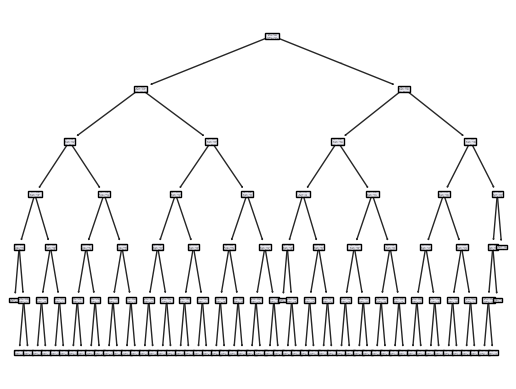

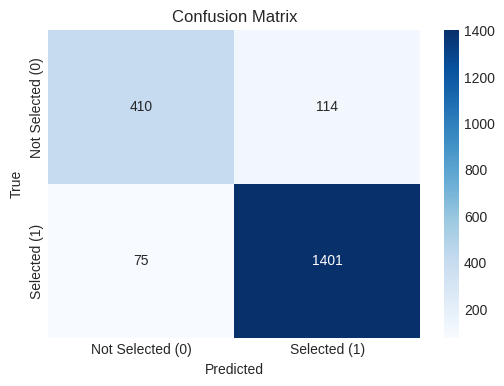


Classification Report:
               precision    recall  f1-score   support

Not Selected       0.85      0.78      0.81       524
    Selected       0.92      0.95      0.94      1476

    accuracy                           0.91      2000
   macro avg       0.89      0.87      0.87      2000
weighted avg       0.90      0.91      0.90      2000

Decision tree training completed:
Training accuracy: 0.932
Test accuracy: 0.905
Top 5 most important features:
  lifetime_prediction: 0.555
  performance_score: 0.219
  data_quality: 0.122
  gradient_quality: 0.038
  rounds_since_participation: 0.026


True

In [10]:
class DecisionTreeSelector:
    """Decision tree-based device selection"""

    def __init__(self):
        self.model = DecisionTreeClassifier(
            max_depth=6,  # Increased for more complex features
            # min_samples_split=25,
            # min_samples_leaf=15,
            random_state=42,
            # class_weight="balanced",  # Handle class imbalance
            criterion="entropy",
        )
        self.scaler = StandardScaler()
        self.is_trained = False
        self.feature_names = [
            "battery_level",
            "memory_ratio",
            "network_reliability",
            "data_quality",
            "rounds_since_participation",
            "reliability_score",
            "data_volume",
            "gradient_quality",
            "performance_score",
            "lifetime_prediction",
            "network_stability",
            "battery_health",
            "memory_efficiency",
            "performance_trend",
            "failure_probability",
            "temperature_impact",
            "workload_intensity",
        ]
        self.feature_importance = None
        self.training_history = []

    def train(self, training_data_path="device_selection_training_data.csv"):
        """Train the decision tree model"""
        try:
            df = pd.read_csv(training_data_path)
            encoder = LabelEncoder()
            df["device_type"] = encoder.fit_transform(df["device_type"])
            X = df[self.feature_names].values
            y = df["should_select"].values

            # Handle any missing values
            X = np.nan_to_num(X, nan=0.0)
            y = np.nan_to_num(y, nan=0)

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train model
            self.model.fit(X_train_scaled, y_train)

            # Store feature importance
            self.feature_importance = dict(
                zip(self.feature_names, self.model.feature_importances_)
            )

            # Evaluate
            train_accuracy = self.model.score(X_train_scaled, y_train)
            test_accuracy = self.model.score(X_test_scaled, y_test)

            # Visualize the decision tree with graphviz
            tree.plot_tree(self.model.fit(X_train_scaled, y_train))

            # Display the confusion matrix
            y_pred = self.model.predict(X_test_scaled)
            cm = confusion_matrix(y_test, y_pred)
            
            plt.figure(figsize=(6, 4))
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["Not Selected (0)", "Selected (1)"],
                yticklabels=["Not Selected (0)", "Selected (1)"],
            )
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.title("Confusion Matrix")
            plt.show()

            print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Not Selected", "Selected"]))

            # Store training history
            training_record = {
                "timestamp": time.time(),
                "train_samples": len(X_train),
                "test_samples": len(X_test),
                "train_accuracy": train_accuracy,
                "test_accuracy": test_accuracy,
                "feature_count": len(self.feature_names),
            }
            self.training_history.append(training_record)

            print(f"Decision tree training completed:")
            print(f"Training accuracy: {train_accuracy:.3f}")
            print(f"Test accuracy: {test_accuracy:.3f}")
            print(f"Top 5 most important features:")

            sorted_importance = sorted(
                self.feature_importance.items(), key=lambda x: x[1], reverse=True
            )
            for feature, importance in sorted_importance[:5]:
                print(f"  {feature}: {importance:.3f}")

            self.is_trained = True
            return True

        except FileNotFoundError:
            print(
                "Training data file not found. Generate data first using generate_decision_tree_training_data()"
            )
            return False
        except Exception as e:
            print(e.with_traceback)
            print(f"Error during training: {e}")
            return False

    def predict_selection_probability(self, device: IoTDevice) -> float:
        """Predict selection probability for a device"""
        if not self.is_trained:
            return 0.5  # Default probability if model not trained

        try:
            features = device.get_selection_features().reshape(1, -1)

            # Handle feature dimension mismatch
            if features.shape[1] != len(self.feature_names):
                print(
                    f"Warning: Feature dimension mismatch. Expected {len(self.feature_names)}, got {features.shape[1]}"
                )
                # Pad with zeros if needed
                if features.shape[1] < len(self.feature_names):
                    padding = np.zeros((1, len(self.feature_names) - features.shape[1]))
                    features = np.concatenate([features, padding], axis=1)
                else:
                    features = features[:, : len(self.feature_names)]

            features_scaled = self.scaler.transform(features)
            probabilities = self.model.predict_proba(features_scaled)
            return probabilities[0][1] if probabilities.shape[1] > 1 else 0.5

        except Exception as e:
            print(f"Error in prediction for device {device.device_id}: {e}")
            return 0.5

    def retrain_with_new_data(self, recent_performance_data: List[Dict]):
        """Retrain model with recent performance data"""
        if not recent_performance_data:
            return False

        # This would implement online learning or incremental updates
        # For now, we'll simulate by adjusting feature weights based on recent performance
        print(f"Retraining with {len(recent_performance_data)} recent samples")
        return True


# Initialize and train the decision tree selector
dt_selector = DecisionTreeSelector()
dt_selector.train()

#### 5.3. Temporal State Evolution and Monitoring

In [11]:
class NetworkHealthMonitor:
    """System-wide network health monitoring"""
    
    def __init__(self):
        self.device_health_history = defaultdict(list)
        self.network_events = []
        self.alert_thresholds = {
            'battery_critical': 10,
            'failure_probability_high': 0.8,
            'network_degraded': 0.3,
            'memory_pressure_high': 0.8
        }
    
    def collect_device_telemetry(self, devices: List[IoTDevice]):
        """Collect telemetry from all devices"""
        current_time = time.time()
        
        for device in devices:
            health_data = {
                'timestamp': current_time,
                'device_id': device.device_id,
                'battery_level': device.battery.current_level,
                'battery_health': device.battery.health_percentage,
                'network_stability': device.bandwidth.connection_stability,
                'memory_pressure': device.memory.memory_pressure,
                'failure_probability': device.health_metrics.failure_probability,
                'performance_score': device._calculate_performance_score(),
                'predicted_lifetime': device.predict_remaining_lifetime()
            }
            
            self.device_health_history[device.device_id].append(health_data)
            
            # Keep only last 1000 records per device
            if len(self.device_health_history[device.device_id]) > 1000:
                self.device_health_history[device.device_id] = \
                    self.device_health_history[device.device_id][-1000:]
            
            # Check for alerts
            self._check_device_alerts(health_data)
    
    def _check_device_alerts(self, health_data: Dict):
        """Check for alert conditions"""
        alerts = []
        
        if health_data['battery_level'] < self.alert_thresholds['battery_critical']:
            alerts.append(f"CRITICAL: Device {health_data['device_id']} battery at {health_data['battery_level']:.1f}%")
        
        if health_data['failure_probability'] > self.alert_thresholds['failure_probability_high']:
            alerts.append(f"WARNING: Device {health_data['device_id']} high failure risk: {health_data['failure_probability']:.2f}")
        
        if health_data['network_stability'] < self.alert_thresholds['network_degraded']:
            alerts.append(f"NETWORK: Device {health_data['device_id']} poor connectivity: {health_data['network_stability']:.2f}")
        
        for alert in alerts:
            self.network_events.append({
                'timestamp': health_data['timestamp'],
                'type': 'ALERT',
                'message': alert
            })
    
    def get_network_health_summary(self, devices: List[IoTDevice]) -> Dict:
        """Get overall network health summary"""
        if not devices:
            return {}
        
        # Collect current metrics
        battery_levels = [d.battery.current_level for d in devices]
        performance_scores = [d._calculate_performance_score() for d in devices]
        failure_probs = [d.health_metrics.failure_probability for d in devices]
        network_stabilities = [d.bandwidth.connection_stability for d in devices]
        
        summary = {
            'total_devices': len(devices),
            'active_devices': len([d for d in devices if d.is_active]),
            'avg_battery_level': np.mean(battery_levels),
            'min_battery_level': np.min(battery_levels),
            'avg_performance_score': np.mean(performance_scores),
            'high_risk_devices': len([p for p in failure_probs if p > 0.7]),
            'network_stability': np.mean(network_stabilities),
            'devices_needing_attention': len([d for d in devices if 
                d.battery.current_level < 20 or 
                d.health_metrics.failure_probability > 0.6 or
                d.bandwidth.connection_stability < 0.4])
        }
        
        return summary

class DeviceFailureSimulator:
    """Simulate realistic device failures and recovery"""
    
    @staticmethod
    def simulate_random_failures(devices: List[IoTDevice], failure_rate: float = 0.001):
        """Simulate random device failures"""
        failed_devices = []
        
        for device in devices:
            # Failure probability increases with device health issues
            base_failure_prob = failure_rate
            health_multiplier = 1 + device.health_metrics.failure_probability * 10
            effective_failure_prob = min(0.1, base_failure_prob * health_multiplier)
            
            if random.random() < effective_failure_prob:
                device.is_active = False
                device.battery.current_level = 0
                failed_devices.append(device.device_id)
                logger.warning(f"Device {device.device_id} failed due to hardware issues")
        
        return failed_devices
    
    @staticmethod
    def simulate_recovery(devices: List[IoTDevice], recovery_rate: float = 0.01):
        """Simulate device recovery (repair/replacement)"""
        recovered_devices = []
        
        for device in devices:
            if not device.is_active and random.random() < recovery_rate:
                # Reset device to operational state
                device.is_active = True
                device.battery.current_level = random.uniform(70, 100)
                device.battery.health_percentage = random.uniform(80, 100)
                device.health_metrics.failure_probability = 0.0
                recovered_devices.append(device.device_id)
                logger.info(f"Device {device.device_id} recovered and back online")
        
        return recovered_devices


#### 5.4. Multi-objectives optimization

##### 5.4.1. Objective Function

In [12]:
class ObjectiveFunction:
    """Multi-objective function definitions for federated learning optimization"""
    
    def __init__(self):
        self.history = {
            'convergence_speed': [],
            'network_lifetime': [],
            'fairness': [],
            'energy_efficiency': [],
            'composite_score': []
        }
    
    @staticmethod
    def convergence_speed_objective(selected_devices: List[IoTDevice], round_num: int) -> float:
        """Objective 1: Maximize convergence speed through gradient quality"""
        if not selected_devices:
            return 0.0
        
        # Weight factors: data quality, gradient history, device capability
        convergence_factors = []
        for device in selected_devices:
            data_quality_score = device.data_quality_score
            gradient_quality = np.mean(device.gradient_quality_history[-3:]) if device.gradient_quality_history else 0.5
            device_capability = device._calculate_performance_score()
            
            # Combine factors (normalized 0-1)
            convergence_factor = (
                0.4 * data_quality_score +
                0.4 * gradient_quality +
                0.2 * device_capability
            )
            convergence_factors.append(convergence_factor)
        
        return np.mean(convergence_factors)
    
    @staticmethod
    def network_lifetime_objective(devices: List[IoTDevice], selected_devices: List[IoTDevice]) -> float:
        """Objective 2: Maximize network lifetime"""
        if not devices:
            return 0.0
        
        # Calculate total network energy
        total_energy = sum(d.battery.current_level * d.battery.current_capacity for d in devices if d.is_active)
        total_capacity = sum(d.battery.current_capacity for d in devices if d.is_active)
        
        if total_capacity == 0:
            return 0.0
        
        current_energy_ratio = total_energy / total_capacity
        
        # Predict energy consumption for selected devices
        energy_consumption = 0
        for device in selected_devices:
            # Estimate energy cost of participation
            training_cost = device.battery.discharge_rate * 0.1  # 6 minutes training
            comm_cost = device.bandwidth.current_uplink * 0.05   # Communication cost
            energy_consumption += training_cost + comm_cost
        
        # Calculate remaining lifetime considering selection impact
        if energy_consumption > 0:
            selection_impact = energy_consumption / max(1, len(devices))
            predicted_lifetime_hours = current_energy_ratio * 100 / max(1, selection_impact)
        else:
            predicted_lifetime_hours = current_energy_ratio * 100
        
        # Normalize to 0-1 scale (assume max reasonable lifetime is 100 hours)
        return min(1.0, predicted_lifetime_hours / 100.0)
    
    @staticmethod
    def fairness_objective(devices: List[IoTDevice], selected_devices: List[IoTDevice]) -> float:
        """Objective 3: Maximize participation fairness"""
        if not devices:
            return 1.0
        
        # Calculate participation variance
        participation_counts = [device.total_participation_count for device in devices if device.is_active]
        
        if len(participation_counts) < 2:
            return 1.0
        
        # Fairness is inverse of participation variance (normalized)
        participation_variance = np.var(participation_counts)
        max_possible_variance = (max(participation_counts) - min(participation_counts)) ** 2 / 4
        
        if max_possible_variance == 0:
            return 1.0
        
        fairness_score = 1.0 - (participation_variance / max_possible_variance)
        return max(0.0, fairness_score)
    
    @staticmethod
    def energy_efficiency_objective(selected_devices: List[IoTDevice]) -> float:
        """Objective 4: Maximize energy efficiency of selection"""
        if not selected_devices:
            return 0.0
        
        efficiency_scores = []
        for device in selected_devices:
            # Energy efficiency = performance per unit energy consumed
            performance_score = device._calculate_performance_score()
            energy_consumption_rate = device.battery.discharge_rate
            
            if energy_consumption_rate > 0:
                efficiency = performance_score / energy_consumption_rate
                efficiency_scores.append(min(1.0, efficiency))
            else:
                efficiency_scores.append(1.0)
        
        return np.mean(efficiency_scores)
    
    def calculate_all_objectives(self, devices: List[IoTDevice], selected_devices: List[IoTDevice], 
                               round_num: int) -> Dict[str, float]:
        """Calculate all objective values"""
        objectives = {
            'convergence_speed': self.convergence_speed_objective(selected_devices, round_num),
            'network_lifetime': self.network_lifetime_objective(devices, selected_devices),
            'fairness': self.fairness_objective(devices, selected_devices),
            'energy_efficiency': self.energy_efficiency_objective(selected_devices)
        }
        
        # Store in history
        for obj_name, value in objectives.items():
            self.history[obj_name].append(value)
        
        return objectives

In [13]:
class ObjectiveWeightManager:
    """Dynamic weight management for multi-objective optimization"""
    
    def __init__(self):
        self.base_weights = {
            'convergence_speed': 0.3,
            'network_lifetime': 0.3,
            'fairness': 0.2,
            'energy_efficiency': 0.2
        }
        self.adaptive_weights = self.base_weights.copy()
        self.weight_history = []
    
    def adapt_weights(self, round_num: int, total_rounds: int, network_state: Dict) -> Dict[str, float]:
        """Dynamically adapt objective weights based on context"""
        # Round progress factor
        progress = round_num / total_rounds
        
        # Early rounds (0-30%): prioritize convergence
        if progress < 0.3:
            weights = {
                'convergence_speed': 0.5,
                'network_lifetime': 0.2,
                'fairness': 0.15,
                'energy_efficiency': 0.15
            }
        # Mid rounds (30-70%): balanced approach
        elif progress < 0.7:
            weights = {
                'convergence_speed': 0.3,
                'network_lifetime': 0.3,
                'fairness': 0.25,
                'energy_efficiency': 0.15
            }
        # Late rounds (70%+): prioritize lifetime and efficiency
        else:
            weights = {
                'convergence_speed': 0.2,
                'network_lifetime': 0.4,
                'fairness': 0.2,
                'energy_efficiency': 0.2
            }
        
        # Adjust based on network health
        avg_battery = network_state.get('avg_battery_level', 50) / 100.0
        high_risk_devices = network_state.get('high_risk_devices', 0)
        total_devices = network_state.get('total_devices', 1)
        
        # Critical battery situation: increase lifetime priority
        if avg_battery < 0.3:
            weights['network_lifetime'] += 0.2
            weights['convergence_speed'] -= 0.1
            weights['energy_efficiency'] -= 0.1
        
        # High failure risk: increase energy efficiency
        if high_risk_devices / max(1, total_devices) > 0.3:
            weights['energy_efficiency'] += 0.15
            weights['convergence_speed'] -= 0.15
        
        # Normalize weights
        total_weight = sum(weights.values())
        weights = {k: v/total_weight for k, v in weights.items()}
        
        self.adaptive_weights = weights
        self.weight_history.append(weights.copy())
        
        return weights


##### 5.4.2. Pareto Optimizer

In [14]:
class ParetoOptimizer:
    """Pareto optimization for multi-objective device selection"""
    
    def __init__(self):
        self.pareto_solutions = []
        self.optimization_history = []
    
    def is_pareto_optimal(self, solution: np.ndarray, objective_values: List[float]) -> bool:
        """Check if a solution is Pareto optimal"""
        for other_solution, other_objectives in self.pareto_solutions:
            # Check if other solution dominates this one
            dominates = all(other_obj >= obj for other_obj, obj in zip(other_objectives, objective_values))
            strictly_better = any(other_obj > obj for other_obj, obj in zip(other_objectives, objective_values))
            
            if dominates and strictly_better:
                return False
        
        return True
    
    def update_pareto_front(self, solution: np.ndarray, objective_values: List[float]):
        """Update Pareto front with new solution"""
        if self.is_pareto_optimal(solution, objective_values):
            # Remove dominated solutions
            self.pareto_solutions = [
                (sol, obj) for sol, obj in self.pareto_solutions
                if not self._dominates(objective_values, obj)
            ]
            # Add new solution
            self.pareto_solutions.append((solution.copy(), objective_values.copy()))
    
    def _dominates(self, obj1: List[float], obj2: List[float]) -> bool:
        """Check if obj1 dominates obj2"""
        better_equal = all(v1 >= v2 for v1, v2 in zip(obj1, obj2))
        strictly_better = any(v1 > v2 for v1, v2 in zip(obj1, obj2))
        return better_equal and strictly_better


#### 5.5. Adaptive Selection Strategy Manager

In [15]:
class AdaptiveSelectionManager:
    """Manages adaptive device selection using multiple strategies"""
    
    def __init__(self, dt_selector: DecisionTreeSelector):
        self.dt_selector = dt_selector
        self.objective_function = ObjectiveFunction()
        self.weight_manager = ObjectiveWeightManager()
        self.pareto_optimizer = ParetoOptimizer()
        self.strategy_performance = {
            'random': {'accuracy': [], 'objectives': []},
            'resource_aware': {'accuracy': [], 'objectives': []},
            'decision_tree': {'accuracy': [], 'objectives': []},
            'multi_objective': {'accuracy': [], 'objectives': []}
        }
        self.current_strategy = 'multi_objective'
    
    def select_optimal_devices(self, devices: List[IoTDevice], selection_size: int, 
                             round_num: int, total_rounds: int, network_state: Dict) -> List[IoTDevice]:
        """Select devices using multi-objective optimization"""
        
        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) <= selection_size:
            return eligible_devices
        
        # Get adaptive weights
        weights = self.weight_manager.adapt_weights(round_num, total_rounds, network_state)
        
        # Generate candidate solutions using different strategies
        candidates = []
        
        # Strategy 1: Decision tree based
        dt_selection = self._get_decision_tree_selection(eligible_devices, selection_size)
        candidates.append(('decision_tree', dt_selection))
        
        # Strategy 2: Greedy multi-objective
        greedy_selection = self._get_greedy_multi_objective_selection(
            eligible_devices, selection_size, weights, round_num
        )
        candidates.append(('greedy_mo', greedy_selection))
        
        # Strategy 3: Random sampling (baseline)
        random_selection = random.sample(eligible_devices, selection_size)
        candidates.append(('random', random_selection))
        
        # Evaluate all candidates
        best_selection = None
        best_score = -1
        
        for strategy_name, selection in candidates:
            if not selection:
                continue
                
            objectives = self.objective_function.calculate_all_objectives(
                devices, selection, round_num
            )
            
            # Calculate weighted composite score
            composite_score = sum(weights[obj] * value for obj, value in objectives.items())
            
            # Update Pareto front
            obj_values = list(objectives.values())
            selection_vector = self._selection_to_vector(devices, selection)
            self.pareto_optimizer.update_pareto_front(selection_vector, obj_values)
            
            if composite_score > best_score:
                best_score = composite_score
                best_selection = selection
        
        return best_selection or eligible_devices[:selection_size]
    
    def _get_decision_tree_selection(self, devices: List[IoTDevice], selection_size: int) -> List[IoTDevice]:
        """Get selection using decision tree"""
        if not self.dt_selector.is_trained:
            return random.sample(devices, min(selection_size, len(devices)))
        
        device_scores = []
        for device in devices:
            probability = self.dt_selector.predict_selection_probability(device)
            device_scores.append((device, probability))
        
        device_scores.sort(key=lambda x: x[1], reverse=True)
        return [device for device, _ in device_scores[:selection_size]]
    
    def _get_greedy_multi_objective_selection(self, devices: List[IoTDevice], selection_size: int, 
                                            weights: Dict, round_num: int) -> List[IoTDevice]:
        """Greedy multi-objective selection"""
        selected = []
        remaining = devices.copy()
        
        for _ in range(selection_size):
            if not remaining:
                break
            
            best_device = None
            best_marginal_score = -1
            
            for device in remaining:
                # Calculate marginal improvement
                temp_selection = selected + [device]
                objectives = self.objective_function.calculate_all_objectives(
                    devices, temp_selection, round_num
                )
                
                marginal_score = sum(weights[obj] * value for obj, value in objectives.items())
                
                if marginal_score > best_marginal_score:
                    best_marginal_score = marginal_score
                    best_device = device
            
            if best_device:
                selected.append(best_device)
                remaining.remove(best_device)
        
        return selected
    
    def _selection_to_vector(self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]) -> np.ndarray:
        """Convert device selection to binary vector"""
        vector = np.zeros(len(all_devices))
        device_to_index = {device.device_id: i for i, device in enumerate(all_devices)}
        
        for device in selected_devices:
            if device.device_id in device_to_index:
                vector[device_to_index[device.device_id]] = 1
        
        return vector
    
    def get_strategy_recommendation(self, network_state: Dict) -> str:
        """Recommend selection strategy based on network state"""
        avg_battery = network_state.get('avg_battery_level', 50)
        network_stability = network_state.get('network_stability', 0.5)
        high_risk_ratio = network_state.get('high_risk_devices', 0) / max(1, network_state.get('total_devices', 1))
        
        # Critical situation: use conservative approach
        if avg_battery < 20 or high_risk_ratio > 0.5:
            return 'resource_aware'
        # Good network health: use advanced optimization
        elif avg_battery > 60 and network_stability > 0.7:
            return 'multi_objective'
        # Default: balanced approach
        else:
            return 'decision_tree'


#### 5.6. Client Selection Policies

In [16]:
class ClientSelectionPolicy:
    """Client/Device selection policy framework"""

    @staticmethod
    def random_selection(
        devices: List[IoTDevice], selection_size: int
    ) -> List[IoTDevice]:
        """Random device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) < selection_size:
            return eligible_devices
        return random.sample(eligible_devices, selection_size)
    
    @staticmethod
    def decision_tree_selection(
        devices: List[IoTDevice], 
        selection_size: int,
        dt_selector: DecisionTreeSelector
    ) -> List[IoTDevice]:
        """Decision tree-based device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]
        
        if not eligible_devices:
            return []
        
        # Get selection probabilities for all eligible devices
        device_scores = []
        for device in eligible_devices:
            probability = dt_selector.predict_selection_probability(device)
            device_scores.append((device, probability))
        
        # Sort by probability and select top devices
        device_scores.sort(key=lambda x: x[1], reverse=True)
        selected = [device for device, _ in device_scores[:selection_size]]
        
        print(f"Decision tree selected {len(selected)} devices with avg probability: "
              f"{np.mean([score for _, score in device_scores[:selection_size]]):.3f}")
        
        return selected

    @staticmethod
    def multi_objective_selection(
        devices: List[IoTDevice], 
        selection_size: int,
        adaptive_manager: AdaptiveSelectionManager,
        round_num: int,
        total_rounds: int,
        network_state: Dict
    ) -> List[IoTDevice]:
        """Multi-objective optimization-based device selection"""
        return adaptive_manager.select_optimal_devices(
            devices, selection_size, round_num, total_rounds, network_state
        )

    @staticmethod
    def resource_aware_selection(
        devices: List[IoTDevice], selection_size: int
    ) -> List[IoTDevice]:
        """Resource-aware device selection (future implementation)"""
        eligible_devices = [d for d in devices if d.can_participate()]

        # Score devices based on resources
        scored_devices = []
        for device in eligible_devices:
            score = (
                device.battery.current_level * 0.4
                + (device.memory.free_ram / device.memory.total_ram)
                * 100
                * 0.3
                + (100 - device.bandwidth.packet_loss) * 0.3
            )
            scored_devices.append((device, score))

        # Select top devices
        scored_devices.sort(key=lambda x: x[1], reverse=True)
        return [d[0] for d in scored_devices[:selection_size]]

#### 5.7. Multi-Objective Analysis and Visualization with Network Lifetime Tracking"

In [17]:
class NetworkLifetimeTracker:
    """Track and visualize network lifetime over the training process"""
    
    def __init__(self):
        self.lifetime_history = []
        self.energy_history = []
        self.device_count_history = []
        self.round_timestamps = []
        self.critical_events = []
    
    def record_round_state(self, devices: List[IoTDevice], round_num: int):
        """Record network state for this round"""
        active_devices = [d for d in devices if d.is_active]
        
        if not active_devices:
            estimated_lifetime = 0
            total_energy = 0
        else:
            # Calculate total remaining energy
            total_energy = sum(d.battery.current_level * d.battery.current_capacity / 100.0 for d in active_devices)
            avg_consumption_rate = np.mean([d.battery.discharge_rate for d in active_devices])
            
            # Estimate network lifetime (when first device dies)
            min_lifetime = min([d.predict_remaining_lifetime() for d in active_devices])
            estimated_lifetime = max(0, min_lifetime)
        
        self.lifetime_history.append(estimated_lifetime)
        self.energy_history.append(total_energy)
        self.device_count_history.append(len(active_devices))
        self.round_timestamps.append(round_num)
        
        # Check for critical events
        if estimated_lifetime < 5:  # Less than 5 hours remaining
            self.critical_events.append({
                'round': round_num,
                'event': 'critical_lifetime',
                'value': estimated_lifetime
            })
        
        battery_levels = [d.battery.current_level for d in active_devices]
        if battery_levels and min(battery_levels) < 10:
            self.critical_events.append({
                'round': round_num,
                'event': 'device_critical_battery',
                'value': min(battery_levels)
            })

def plot_multi_objective_analysis(objective_history: Dict, lifetime_tracker: NetworkLifetimeTracker, 
                                save_plots: bool = True):
    """Create comprehensive multi-objective analysis plots"""
    
    if not objective_history['convergence_speed']:
        print("No objective history available for plotting")
        return
    
    # Create subplot layout
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Network Lifetime Over Training Process
    ax1 = fig.add_subplot(gs[0, :])
    rounds = lifetime_tracker.round_timestamps
    lifetimes = lifetime_tracker.lifetime_history
    
    ax1.plot(rounds, lifetimes, 'b-', linewidth=2, marker='o', markersize=4, label='Predicted Network Lifetime')
    ax1.fill_between(rounds, lifetimes, alpha=0.3)
    
    # Mark critical events
    for event in lifetime_tracker.critical_events:
        if event['event'] == 'critical_lifetime':
            ax1.axvline(x=event['round'], color='red', linestyle='--', alpha=0.7, label='Critical Lifetime Event')
        elif event['event'] == 'device_critical_battery':
            ax1.axvline(x=event['round'], color='orange', linestyle=':', alpha=0.7, label='Device Critical Battery')
    
    ax1.set_title('Network Lifetime Prediction Over Training Process', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Training Round')
    ax1.set_ylabel('Estimated Network Lifetime (hours)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add text annotations for critical points
    if lifetimes:
        min_lifetime_idx = np.argmin(lifetimes)
        min_lifetime = lifetimes[min_lifetime_idx]
        min_round = rounds[min_lifetime_idx]
        ax1.annotate(f'Min Lifetime: {min_lifetime:.1f}h\n(Round {min_round})',
                    xy=(min_round, min_lifetime), xytext=(min_round + len(rounds)*0.1, min_lifetime + max(lifetimes)*0.1),
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # Plot 2: All Objectives Over Time
    ax2 = fig.add_subplot(gs[1, :])
    rounds = range(len(objective_history['convergence_speed']))
    
    ax2.plot(rounds, objective_history['convergence_speed'], 'g-', marker='s', label='Convergence Speed', linewidth=2)
    ax2.plot(rounds, objective_history['network_lifetime'], 'b-', marker='^', label='Network Lifetime', linewidth=2)
    ax2.plot(rounds, objective_history['fairness'], 'r-', marker='o', label='Fairness', linewidth=2)
    ax2.plot(rounds, objective_history['energy_efficiency'], 'm-', marker='d', label='Energy Efficiency', linewidth=2)
    
    ax2.set_title('Multi-Objective Performance Over Training Rounds', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Training Round')
    ax2.set_ylabel('Objective Value (0-1)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Energy and Device Count Evolution
    ax3 = fig.add_subplot(gs[2, 0])
    ax3_twin = ax3.twinx()
    
    line1 = ax3.plot(lifetime_tracker.round_timestamps, lifetime_tracker.energy_history, 'g-', marker='o', label='Total Energy')
    line2 = ax3_twin.plot(lifetime_tracker.round_timestamps, lifetime_tracker.device_count_history, 'r-', marker='s', label='Active Devices')
    
    ax3.set_xlabel('Training Round')
    ax3.set_ylabel('Total Energy (mAh)', color='g')
    ax3_twin.set_ylabel('Active Device Count', color='r')
    ax3.tick_params(axis='y', labelcolor='g')
    ax3_twin.tick_params(axis='y', labelcolor='r')
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='upper right')
    ax3.set_title('Energy and Device Evolution')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Objective Correlation Matrix
    ax4 = fig.add_subplot(gs[2, 1])
    obj_data = np.array([
        objective_history['convergence_speed'],
        objective_history['network_lifetime'],
        objective_history['fairness'],
        objective_history['energy_efficiency']
    ])
    
    correlation_matrix = np.corrcoef(obj_data)
    im = ax4.imshow(correlation_matrix, cmap='RdBu', vmin=-1, vmax=1)
    ax4.set_xticks(range(4))
    ax4.set_yticks(range(4))
    ax4.set_xticklabels(['Convergence', 'Lifetime', 'Fairness', 'Efficiency'], rotation=45)
    ax4.set_yticklabels(['Convergence', 'Lifetime', 'Fairness', 'Efficiency'])
    ax4.set_title('Objective Correlation Matrix')
    
    # Add correlation values
    for i in range(4):
        for j in range(4):
            text = ax4.text(j, i, f'{correlation_matrix[i, j]:.2f}', 
                           ha="center", va="center", color="white" if abs(correlation_matrix[i, j]) > 0.5 else "black")
    
    plt.colorbar(im, ax=ax4)
    
    # Plot 5: Trade-off Analysis
    ax5 = fig.add_subplot(gs[2, 2])
    ax5.scatter(objective_history['convergence_speed'], objective_history['network_lifetime'], 
               c=range(len(rounds)), cmap='viridis', alpha=0.7)
    ax5.set_xlabel('Convergence Speed')
    ax5.set_ylabel('Network Lifetime')
    ax5.set_title('Convergence vs Lifetime Trade-off')
    ax5.grid(True, alpha=0.3)
    
    # Add colorbar for rounds
    scatter = ax5.scatter(objective_history['convergence_speed'], objective_history['network_lifetime'], 
                         c=range(len(rounds)), cmap='viridis', alpha=0)  # Invisible for colorbar
    cbar = plt.colorbar(scatter, ax=ax5)
    cbar.set_label('Training Round')
    
    # Plot 6: Performance Distribution
    ax6 = fig.add_subplot(gs[3, :])
    
    # Box plots for all objectives
    data_to_plot = [
        objective_history['convergence_speed'],
        objective_history['network_lifetime'],
        objective_history['fairness'],
        objective_history['energy_efficiency']
    ]
    
    box_plot = ax6.boxplot(data_to_plot, labels=['Convergence\nSpeed', 'Network\nLifetime', 'Fairness', 'Energy\nEfficiency'],
                          patch_artist=True, notch=True)
    
    # Color the boxes
    colors = ['lightgreen', 'lightblue', 'lightcoral', 'lightpink']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax6.set_title('Objective Performance Distribution', fontsize=14, fontweight='bold')
    ax6.set_ylabel('Objective Value')
    ax6.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = "Performance Statistics:\n"
    for i, (obj_name, values) in enumerate(objective_history.items()):
        if values:
            mean_val = np.mean(values)
            std_val = np.std(values)
            stats_text += f"{obj_name}: μ={mean_val:.3f}, σ={std_val:.3f}\n"
    
    ax6.text(1.02, 0.5, stats_text, transform=ax6.transAxes, fontsize=10,
            verticalalignment='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))
    
    plt.suptitle('Multi-Objective Federated Learning Analysis Dashboard', fontsize=16, fontweight='bold')
    
    if save_plots:
        plt.savefig('multi_objective_analysis.png', dpi=300, bbox_inches='tight')
        print("Multi-objective analysis plots saved to 'multi_objective_analysis.png'")
    
    plt.show()

def plot_pareto_frontier_3d(pareto_solutions: List, objective_names: List[str] = None):
    """Plot 3D Pareto frontier for first 3 objectives"""
    if len(pareto_solutions) < 2:
        print("Insufficient Pareto solutions for 3D visualization")
        return
    
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract first 3 objectives
    obj1 = [sol[1][0] for sol in pareto_solutions]  # Convergence speed
    obj2 = [sol[1][1] for sol in pareto_solutions]  # Network lifetime  
    obj3 = [sol[1][2] for sol in pareto_solutions]  # Fairness
    
    # Create 3D scatter plot
    scatter = ax.scatter(obj1, obj2, obj3, c=range(len(obj1)), cmap='viridis', 
                        s=50, alpha=0.7, edgecolors='black')
    
    # Set labels
    ax.set_xlabel(objective_names[0] if objective_names else 'Convergence Speed')
    ax.set_ylabel(objective_names[1] if objective_names else 'Network Lifetime')
    ax.set_zlabel(objective_names[2] if objective_names else 'Fairness')
    ax.set_title('3D Pareto Frontier')
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax, label='Solution Index')
    
    plt.show()

def plot_selection_policy_effectiveness(experiment_results: Dict, save_plot: bool = True):
    """Create comprehensive selection policy effectiveness comparison"""
    
    if not experiment_results:
        print("No experiment results available for effectiveness comparison")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Selection Policy Effectiveness Comparison', fontsize=16, fontweight='bold')
    
    policies = list(experiment_results.keys())
    colors = ['red', 'blue', 'green', 'purple', 'orange'][:len(policies)]
    
    # Plot 1: Network Survival Rate Over Rounds
    ax1 = axes[0, 0]
    for i, policy in enumerate(policies):
        if experiment_results[policy]['network_lifetime_progression']:
            rounds = range(len(experiment_results[policy]['network_lifetime_progression']))
            lifetimes = experiment_results[policy]['network_lifetime_progression']
            
            # Calculate survival rate (devices still above critical threshold)
            survival_rates = []
            for lifetime in lifetimes:
                survival_rate = min(1.0, lifetime / 10.0)  # Normalize by 10 hours threshold
                survival_rates.append(survival_rate)
            
            ax1.plot(rounds, survival_rates, marker='o', label=policy, 
                    color=colors[i], linewidth=2, markersize=4)
    
    ax1.set_title('Network Survival Rate Over Training')
    ax1.set_xlabel('Training Round')
    ax1.set_ylabel('Network Survival Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.1)
    
    # Plot 2: Convergence Effectiveness
    ax2 = axes[0, 1]
    convergence_scores = []
    policy_names = []
    
    for policy in policies:
        if (experiment_results[policy]['objective_values']['convergence_speed'] and
            experiment_results[policy]['final_accuracy'] > 0):
            
            # Effectiveness = final accuracy * average convergence speed
            avg_convergence = np.mean(experiment_results[policy]['objective_values']['convergence_speed'])
            final_acc = experiment_results[policy]['final_accuracy']
            effectiveness = avg_convergence * final_acc
            
            convergence_scores.append(effectiveness)
            policy_names.append(policy)
    
    if convergence_scores:
        bars = ax2.bar(policy_names, convergence_scores, color=colors[:len(policy_names)], alpha=0.7)
        ax2.set_title('Convergence Effectiveness Score')
        ax2.set_ylabel('Effectiveness (Convergence × Accuracy)')
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar, score in zip(bars, convergence_scores):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{score:.3f}', ha='center', va='bottom')
    
    # Plot 3: Energy Efficiency Comparison
    ax3 = axes[0, 2]
    energy_efficiency_data = []
    
    for policy in policies:
        if experiment_results[policy]['objective_values']['energy_efficiency']:
            avg_efficiency = np.mean(experiment_results[policy]['objective_values']['energy_efficiency'])
            energy_efficiency_data.append(avg_efficiency)
        else:
            energy_efficiency_data.append(0)
    
    bars = ax3.bar(policies, energy_efficiency_data, color=colors, alpha=0.7)
    ax3.set_title('Average Energy Efficiency')
    ax3.set_ylabel('Energy Efficiency Score')
    ax3.tick_params(axis='x', rotation=45)
    
    for bar, eff in zip(bars, energy_efficiency_data):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{eff:.3f}', ha='center', va='bottom')
    
    # Plot 4: Fairness Progression
    ax4 = axes[1, 0]
    for i, policy in enumerate(policies):
        if experiment_results[policy]['objective_values']['fairness']:
            rounds = range(len(experiment_results[policy]['objective_values']['fairness']))
            fairness_values = experiment_results[policy]['objective_values']['fairness']
            ax4.plot(rounds, fairness_values, marker='s', label=policy, 
                    color=colors[i], linewidth=2, markersize=4)
    
    ax4.set_title('Fairness Evolution Over Training')
    ax4.set_xlabel('Training Round')
    ax4.set_ylabel('Fairness Score')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Policy Effectiveness Radar
    ax5 = axes[1, 1]
    ax5.remove()
    ax5 = fig.add_subplot(2, 3, 5, projection='polar')
    
    categories = ['Convergence', 'Lifetime', 'Fairness', 'Energy Eff.']
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    for i, policy in enumerate(policies):
        if all(experiment_results[policy]['objective_values'][obj] for obj in 
               ['convergence_speed', 'network_lifetime', 'fairness', 'energy_efficiency']):
            
            values = [
                np.mean(experiment_results[policy]['objective_values']['convergence_speed']),
                np.mean(experiment_results[policy]['objective_values']['network_lifetime']),
                np.mean(experiment_results[policy]['objective_values']['fairness']),
                np.mean(experiment_results[policy]['objective_values']['energy_efficiency'])
            ]
            values += values[:1]
            
            ax5.plot(angles, values, marker='o', linewidth=2, label=policy, color=colors[i])
            ax5.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(categories)
    ax5.set_ylim(0, 1)
    ax5.set_title('Multi-Dimensional Effectiveness', y=1.08)
    ax5.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    
    # Plot 6: Overall Effectiveness Ranking
    ax6 = axes[1, 2]
    
    # Calculate overall effectiveness score
    overall_scores = {}
    for policy in policies:
        if all(experiment_results[policy]['objective_values'][obj] for obj in 
               ['convergence_speed', 'network_lifetime', 'fairness', 'energy_efficiency']):
            
            # Weighted composite score
            conv_score = np.mean(experiment_results[policy]['objective_values']['convergence_speed']) * 0.3
            life_score = np.mean(experiment_results[policy]['objective_values']['network_lifetime']) * 0.3
            fair_score = np.mean(experiment_results[policy]['objective_values']['fairness']) * 0.2
            energy_score = np.mean(experiment_results[policy]['objective_values']['energy_efficiency']) * 0.2
            
            overall_scores[policy] = conv_score + life_score + fair_score + energy_score
    
    if overall_scores:
        sorted_policies = sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)
        policies_sorted = [p[0] for p in sorted_policies]
        scores_sorted = [p[1] for p in sorted_policies]
        
        bars = ax6.barh(policies_sorted, scores_sorted, color=[colors[policies.index(p)] for p in policies_sorted])
        ax6.set_title('Overall Effectiveness Ranking')
        ax6.set_xlabel('Composite Effectiveness Score')
        
        # Add value labels
        for bar, score in zip(bars, scores_sorted):
            ax6.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{score:.3f}', ha='left', va='center')
    
    plt.tight_layout()
    if save_plot:
        plt.savefig('selection_policy_effectiveness_comparison.png', dpi=300, bbox_inches='tight')
        print("Policy effectiveness comparison saved to 'selection_policy_effectiveness_comparison.png'")
    
    plt.show()


#### 5.8. Autonomic Manager (Gateway)

In [18]:
class Gateway:
    def __init__(
        self,
        gateway_id: str = "gateway_001",
        location: Tuple[float, float] = (0.0, 0.0),
    ):
        self.gateway_id = gateway_id
        self.location = location
        self.connected_devices: Dict[str, IoTDevice] = {}
        self.selected_devices: List[IoTDevice] = []
        self.received_packets: List[Packet] = []
        self.monitoring_data: Dict[str, List[Dict]] = {}
        self.is_running = False
        self.creation_time = time.time()
        self.health_monitor = NetworkHealthMonitor()
        self.last_health_check = time.time()
        self.device_failure_simulator = DeviceFailureSimulator()
        self.adaptive_manager = None  # Will be set during initialization
        self.objective_function = ObjectiveFunction()
        self.lifetime_tracker = NetworkLifetimeTracker()
        self.round_objectives = []

        # Gateway capabilities
        self.total_bandwidth = 100.0  # Mbps
        self.current_bandwidth_usage = 0.0
        self.max_devices = 1000
        self.packet_processing_delay = 0.001  # seconds per packet

        # Gateway statistics
        self.stats = {
            "total_packets_processed": 0,
            "packets_dropped": 0,
            "average_latency": 0.0,
            "peak_bandwidth_usage": 0.0,
            "device_failures": 0,
        }
        self.packet_history = []
        self.round_statistics = []

        logger.info(f"Gateway {gateway_id} initialized at {location}")

    def set_adaptive_manager(self, adaptive_manager: AdaptiveSelectionManager):
        """Set the adaptive selection manager"""
        self.adaptive_manager = adaptive_manager

    def calculate_round_objectives(
        self, selected_devices: List[IoTDevice], round_num: int
    ):
        """Calculate and store objective values for this round"""
        all_devices = list(self.connected_devices.values())
        objectives = self.objective_function.calculate_all_objectives(
            all_devices, selected_devices, round_num
        )

        # Record network lifetime state
        self.lifetime_tracker.record_round_state(all_devices, round_num)

        self.round_objectives.append(
            {
                "round": round_num,
                "objectives": objectives,
                "selected_count": len(selected_devices),
                "total_devices": len(all_devices),
            }
        )

        return objectives

    def adapt_selection_strategy(self, round_num: int, total_rounds: int) -> str:
        """Dynamically adapt selection strategy based on performance"""
        if not self.adaptive_manager:
            return "random"

        # Get current network health
        health_summary = self.monitor_network_health()

        # Get strategy recommendation
        recommended_strategy = self.adaptive_manager.get_strategy_recommendation(
            health_summary
        )

        return recommended_strategy

    def analyze_selection_performance(self) -> Dict:
        """Analyze the performance of different selection strategies"""
        if not self.round_objectives:
            return {}

        analysis = {
            "total_rounds": len(self.round_objectives),
            "avg_objectives": {},
            "objective_trends": {},
            "network_lifetime_analysis": {},
        }

        # Calculate average objectives
        for obj_name in [
            "convergence_speed",
            "network_lifetime",
            "fairness",
            "energy_efficiency",
        ]:
            values = [
                round_data["objectives"][obj_name]
                for round_data in self.round_objectives
            ]
            analysis["avg_objectives"][obj_name] = {
                "mean": np.mean(values),
                "std": np.std(values),
                "min": np.min(values),
                "max": np.max(values),
            }

            # Trend analysis (slope of linear regression)
            if len(values) > 2:
                rounds = list(range(len(values)))
                trend_slope = np.polyfit(rounds, values, 1)[0]
                analysis["objective_trends"][obj_name] = trend_slope

        # Network lifetime analysis
        if self.lifetime_tracker.lifetime_history:
            analysis["network_lifetime_analysis"] = {
                "initial_lifetime": self.lifetime_tracker.lifetime_history[0],
                "final_lifetime": self.lifetime_tracker.lifetime_history[-1],
                "min_lifetime": min(self.lifetime_tracker.lifetime_history),
                "avg_lifetime": np.mean(self.lifetime_tracker.lifetime_history),
                "critical_events": len(self.lifetime_tracker.critical_events),
                "lifetime_degradation_rate": (
                    self.lifetime_tracker.lifetime_history[0]
                    - self.lifetime_tracker.lifetime_history[-1]
                )
                / len(self.lifetime_tracker.lifetime_history),
            }

        return analysis

    def register_device(self, device: IoTDevice):
        """Register an IoT device with the gateway"""
        if len(self.connected_devices) >= self.max_devices:
            logger.error(
                f"Gateway capacity exceeded. Cannot register device {device.device_id}"
            )
            return False

        self.connected_devices[device.device_id] = device
        self.monitoring_data[device.device_id] = []
        logger.info(
            f"Device {device.device_id} registered with gateway at {device.location}"
        )
        return True

    def monitor_network_health(self):
        """Monitor overall network health"""
        devices = list(self.connected_devices.values())
        self.health_monitor.collect_device_telemetry(devices)

        # Simulate device failures and recoveries
        failed = self.device_failure_simulator.simulate_random_failures(devices)
        recovered = self.device_failure_simulator.simulate_recovery(devices)

        if failed:
            logger.warning(f"Devices failed this round: {failed}")
        if recovered:
            logger.info(f"Devices recovered this round: {recovered}")

        return self.health_monitor.get_network_health_summary(devices)

    def update_all_device_states(self, time_delta: float):
        """Update temporal states for all connected devices"""
        for device in self.connected_devices.values():
            device.simulate_time_passage(time_delta)

    def _train_selection_model(self):
        """Train a decision tree model to predict device reliability"""
        pass

    def receive_packet(self, packet: Packet):
        """Process received packet and extract monitoring data"""
        processing_start = time.time()

        # Check if gateway is overloaded
        current_load = len(self.received_packets) * self.packet_processing_delay
        if current_load > 1.0:  # More than 1 second of processing backlog
            self.stats["packets_dropped"] += 1
            logger.warning(
                f"Packet dropped due to gateway overload from {packet.source_id}"
            )
            return False

        self.received_packets.append(packet)
        self.stats["total_packets_processed"] += 1

        # Store monitoring data
        if packet.data and packet.source_id in self.monitoring_data:
            data = {
                "timestamp": packet.timestamp,
                "packet_size": packet.size,
                "packet_type": packet.packet_type,
                # "priority": packet.priority,
                "retry_count": packet.retry_count,
                "processing_delay": time.time() - processing_start,
                **packet.data,
            }
            self.monitoring_data[packet.source_id].append(data)

            # Keep only last 1000 records per device to manage memory
            if len(self.monitoring_data[packet.source_id]) > 1000:
                self.monitoring_data[packet.source_id] = self.monitoring_data[
                    packet.source_id
                ][-1000:]

        # Update gateway statistics
        processing_time = time.time() - processing_start
        self.stats["average_latency"] = (
            self.stats["average_latency"] * 0.9 + processing_time * 0.1
        )

        return True

    def select_devices(
        self,
        devices: List[IoTDevice],
        selection_size: int,
        policy: str,
        round_num: int,
        total_rounds: int,
        dt_selector=None,
    ) -> None:
        """Select devices for training round"""
        if policy == "random":
            self.selected_devices = ClientSelectionPolicy.random_selection(
                devices, selection_size
            )
        elif policy == "resource_aware":
            self.selected_devices = ClientSelectionPolicy.resource_aware_selection(
                devices, selection_size
            )
        elif policy == "decision_tree":
            if dt_selector and dt_selector.is_trained:
                self.selected_devices = ClientSelectionPolicy.decision_tree_selection(
                    devices, selection_size, dt_selector
                )
            else:
                print("Decision tree not trained, falling back to random selection")
                self.selected_devices = ClientSelectionPolicy.random_selection(
                    devices, selection_size
                )
        elif policy == "multi_objective":
            if self.adaptive_manager:
                health_summary = self.monitor_network_health()
                self.selected_devices = ClientSelectionPolicy.multi_objective_selection(
                    devices,
                    selection_size,
                    self.adaptive_manager,
                    round_num,
                    total_rounds,
                    health_summary,
                )
            else:
                print("Adaptive manager not set, falling back to decision tree")
                if dt_selector and dt_selector.is_trained:
                    self.selected_devices = (
                        ClientSelectionPolicy.decision_tree_selection(
                            devices, selection_size, dt_selector
                        )
                    )
                else:
                    self.selected_devices = ClientSelectionPolicy.random_selection(
                        devices, selection_size
                    )
        else:
            raise ValueError(f"Unknown policy: {policy}")

    def broadcast_global_model(
        self,
        round_num: int,
        global_model: dict[str, any],
    ):
        """Simulate broadcasting global model to selected devices"""

        for device in self.selected_devices:
            packet = device.train_model_and_generate_packet(
                destination=self.gateway_id,
                epochs=1,
                global_update=global_model,
                round_num=round_num,
            )
            if packet:
                transmission_result = device.transmit_packet()
                if transmission_result is not None:
                    success, transmitted_packet = transmission_result
                    if success and transmitted_packet and transmitted_packet.data:
                        self.receive_packet(transmitted_packet)

        print(
            f"Round {round_num + 1}: Broadcasting global model to {len(self.selected_devices)} devices"
        )

### 6. Cloud Server building

#### 6.1. Model Aggregation Methods

In [19]:
class AggregationMethods:
    """Federated learning aggregation methods"""

    def fed_avg(weights_list: List[Dict]) -> Dict:
        avg_weights = copy.deepcopy(weights_list[0])
        for key in avg_weights:
            for i in range(1, len(weights_list)):
                avg_weights[key] += weights_list[i][key]
            avg_weights[key] = avg_weights[key] / len(weights_list)
        return avg_weights

    def fed_median(self, weights_list):
        median_weights = copy.deepcopy(weights_list[0])
        for key in median_weights:
            all_weights = torch.stack([weights[key] for weights in weights_list], dim=0)
            median_weights[key] = torch.median(all_weights, dim=0).values
        return median_weights
    def fed_round_robin(self, weights_list, round_num):
        index = round_num % len(weights_list)
        return weights_list[index]
    def fed_weighted_avg(self, weights_list, weights):
        avg_weights = copy.deepcopy(weights_list[0])
        total_weight = sum(weights)
        for key in avg_weights:
            avg_weights[key] = sum(weights[i] * weights_list[i][key] for i in range(len(weights_list))) / total_weight
        return avg_weights
    def fed_krum(self, weights_list, f=1):
        num_clients = len(weights_list)
        scores = []
        for i in range(num_clients):
            distances = []
            for j in range(num_clients):
                if i != j:
                    dist = sum(torch.sum((weights_list[i][key] - weights_list[j][key])**2).item() for key in weights_list[i])
                    distances.append(dist)
            distances.sort()
            score = sum(distances[:num_clients - f - 2])
            scores.append(score)
        krum_index = scores.index(min(scores))
        return weights_list[krum_index]
    def fed_bulyan(self, weights_list, f=1):
        num_clients = len(weights_list)
        selected = []
        temp_weights = weights_list.copy()
        for _ in range(num_clients - 2 * f):
            scores = []
            for i in range(len(temp_weights)):
                distances = []
                for j in range(len(temp_weights)):
                    if i != j:
                        dist = sum(torch.sum((temp_weights[i][key] - temp_weights[j][key])**2).item() for key in temp_weights[i])
                        distances.append(dist)
                distances.sort()
                score = sum(distances[:num_clients - f - 2])
                scores.append(score)
            min_index = scores.index(min(scores))
            selected.append(temp_weights[min_index])
            temp_weights.pop(min_index)
        return self.fed_avg(selected)


#### 6.2. Central/Cloud Server

In [20]:
class CloudServer:
    def __init__(
        self, server_id: str = "cloud_server", global_model: SimpleNet = SimpleNet()
    ):
        self.server_id = server_id
        self.connected_gateways: Dict[str, Gateway] = {}
        self.global_model = global_model
        self.global_model_state = None
        self.creation_time = time.time()

        # Server capabilities
        self.model_update_interval = 3600  # 1 hour
        self.last_model_update = time.time()
        self.stats = {
            "total_gateways": 0,
            "total_devices": 0,
            "model_updates": 0,
            "aggregation_time": 0.0,
        }
        logger.info(f"Cloud server {server_id} initialized")

    def register_gateway(self, gateway: Gateway):
        """Register a gateway with the cloud server"""
        if gateway.gateway_id in self.connected_gateways:
            logger.warning(f"Gateway {gateway.gateway_id} already registered")
            return False

        self.connected_gateways[gateway.gateway_id] = gateway
        self.stats["total_gateways"] += len(gateway.connected_devices)
        logger.info(f"Gateway {gateway.gateway_id} registered with cloud server")
        return True

    def aggregate_model_updates(self, packets: List[Dict] = []):
        """Aggregate model updates from all connected clients/devices"""
        if not packets:
            logger.warning("No packets received for aggregation")
            return
        self.global_model_state = AggregationMethods.fed_avg(weights_list=packets)
        self.global_model.load_state_dict(self.global_model_state)
        self.last_model_update = time.time()
        logger.info(f"Global model updated with {len(packets)} local models")

    def collect_system_telemetry(self) -> Dict:
        """Collect system-wide telemetry for decision tree retraining"""
        telemetry = {
            "timestamp": time.time(),
            "total_devices": sum(
                len(gw.connected_devices) for gw in self.connected_gateways.values()
            ),
            "gateway_health": {},
        }

        for gw_id, gateway in self.connected_gateways.items():
            health_summary = gateway.monitor_network_health()
            telemetry["gateway_health"][gw_id] = health_summary

        return telemetry

    def distribute_global_model(self):
        """Distribute the global model to all connected gateways and their devices"""
        # for gateway in self.connected_gateways.values():
        #     for device in gateway.connected_devices.values():
        #         device.local_model.load_state_dict(self.global_model.state_dict())
        # logger.info("Global model distributed to all connected devices")
        return

### 7. Simulator building

#### 7.1. Enhanced Monitoring Dashboard

In [21]:
def create_device_health_dashboard(devices: List[IoTDevice], save_plot: bool = True):
    """Create visual dashboard of device health metrics"""
    if not devices:
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('IoT Device Health Dashboard', fontsize=16)
    
    # Battery levels
    battery_levels = [d.battery.current_level for d in devices if d.is_active]
    axes[0, 0].hist(battery_levels, bins=20, alpha=0.7, color='green')
    axes[0, 0].set_title('Battery Level Distribution')
    axes[0, 0].set_xlabel('Battery Level (%)')
    axes[0, 0].axvline(x=20, color='red', linestyle='--', label='Critical')
    axes[0, 0].legend()
    
    # Performance scores
    perf_scores = [d._calculate_performance_score() for d in devices if d.is_active]
    axes[0, 1].hist(perf_scores, bins=20, alpha=0.7, color='blue')
    axes[0, 1].set_title('Performance Score Distribution')
    axes[0, 1].set_xlabel('Performance Score')
    
    # Failure probabilities
    failure_probs = [d.health_metrics.failure_probability for d in devices if d.is_active]
    axes[0, 2].hist(failure_probs, bins=20, alpha=0.7, color='red')
    axes[0, 2].set_title('Failure Probability Distribution')
    axes[0, 2].set_xlabel('Failure Probability')
    
    # Network stability
    network_stability = [d.bandwidth.connection_stability for d in devices if d.is_active]
    axes[1, 0].hist(network_stability, bins=20, alpha=0.7, color='purple')
    axes[1, 0].set_title('Network Stability Distribution')
    axes[1, 0].set_xlabel('Connection Stability')
    
    # Device locations colored by health
    x_coords = [d.location[0] for d in devices if d.is_active]
    y_coords = [d.location[1] for d in devices if d.is_active]
    colors = [d._calculate_performance_score() for d in devices if d.is_active]
    
    scatter = axes[1, 1].scatter(x_coords, y_coords, c=colors, cmap='RdYlGn', alpha=0.7)
    axes[1, 1].set_title('Device Health by Location')
    axes[1, 1].set_xlabel('X Coordinate')
    axes[1, 1].set_ylabel('Y Coordinate')
    plt.colorbar(scatter, ax=axes[1, 1], label='Performance Score')
    
    # Device type health comparison
    device_types = {}
    for device in devices:
        if device.is_active:
            if device.device_type not in device_types:
                device_types[device.device_type] = []
            device_types[device.device_type].append(device._calculate_performance_score())
    
    if device_types:
        type_names = list(device_types.keys())
        type_scores = [np.mean(scores) for scores in device_types.values()]
        axes[1, 2].bar(type_names, type_scores, alpha=0.7)
        axes[1, 2].set_title('Average Performance by Device Type')
        axes[1, 2].set_ylabel('Performance Score')
        axes[1, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    if save_plot:
        plt.savefig('device_health_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_system_health_report(health_summary: Dict):
    """Print formatted system health report"""
    print("\n" + "="*60)
    print("SYSTEM HEALTH REPORT")
    print("="*60)
    print(f"Total Devices: {health_summary.get('total_devices', 0)}")
    print(f"Active Devices: {health_summary.get('active_devices', 0)}")
    print(f"Average Battery Level: {health_summary.get('avg_battery_level', 0):.1f}%")
    print(f"Minimum Battery Level: {health_summary.get('min_battery_level', 0):.1f}%")
    print(f"Average Performance Score: {health_summary.get('avg_performance_score', 0):.3f}")
    print(f"High Risk Devices: {health_summary.get('high_risk_devices', 0)}")
    print(f"Network Stability: {health_summary.get('network_stability', 0):.3f}")
    print(f"Devices Needing Attention: {health_summary.get('devices_needing_attention', 0)}")
    
    # Health status classification
    if health_summary.get('avg_battery_level', 0) > 50:
        battery_status = "GOOD"
    elif health_summary.get('avg_battery_level', 0) > 20:
        battery_status = "WARNING"
    else:
        battery_status = "CRITICAL"
    
    network_stability = health_summary.get('network_stability', 0)
    if network_stability > 0.7:
        network_status = "EXCELLENT"
    elif network_stability > 0.5:
        network_status = "GOOD"
    elif network_stability > 0.3:
        network_status = "DEGRADED"
    else:
        network_status = "POOR"
    
    print(f"\nOVERALL STATUS:")
    print(f"Battery Health: {battery_status}")
    print(f"Network Health: {network_status}")
    print("="*60)


#### 7.2. Simulator

In [22]:
class FederatedLearningSystem:
    def __init__(
        self,
        selection_size: int = 6,
        simulation_area: Tuple[int, int] = (1000, 1000),
        data_heterogeneity: float = 0.5,
        enable_multi_objective: bool = True,
    ):
        self.num_devices: int = 0
        self.selection_size = selection_size
        self.gateway = Gateway()
        self.cloud_server = CloudServer()
        self.devices = List[IoTDevice]
        self.system_start_time = None
        self.system_end_time = None
        self.simulation_area = simulation_area  # (width, height) in meters
        self.real_time_data: Dict[str, Dict] = {}
        self.data_heterogeneity = data_heterogeneity
        self.client_datasets = {}
        self.client_stats = {}
        self.dt_selector = DecisionTreeSelector()
        self.enable_multi_objective = enable_multi_objective
        self.adaptive_manager = None
        self.objective_history = {
            "convergence_speed": [],
            "network_lifetime": [],
            "fairness": [],
            "energy_efficiency": [],
        }
        self.selection_performance_metrics = {}
        self.experiment_results = {}

        # Register gateway with Cloud Server
        self.cloud_server.register_gateway(self.gateway)

    # Create devices with configurations
    def add_device(
        self,
        device_id: str,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Optional[Tuple[float, float]] = None,
    ):
        """Add IoT device with enhanced positioning and configuration"""
        if location is None:
            # Random placement within simulation area
            location = (
                random.uniform(0, self.simulation_area[0]),
                random.uniform(0, self.simulation_area[1]),
            )

        device = IoTDevice(
            device_id,
            device_type,
            initial_battery,
            location,
            local_model=SimpleNet(),
        )

        if self.gateway.register_device(device):
            self.num_devices += 1
            self.real_time_data[device_id] = {
                "timestamps": [],
                "battery": [],
                "memory": [],
                "bandwidth": [],
                "packet_loss": [],
                "latency": [],
                "temperature": [],
            }
            logger.info(f"Device {device_id} ({device_type}) added at {location}")
            return True
        return False

    def add_device_cluster(
        self,
        cluster_center: Tuple[float, float],
        cluster_radius: float,
        device_count: int,
        device_type: str = "sensor",
    ):
        """Add a cluster of devices around a central point"""
        for i in range(device_count):
            # Random position within cluster radius
            angle = random.uniform(0, 2 * np.pi)
            radius = random.uniform(0, cluster_radius)

            x = cluster_center[0] + radius * np.cos(angle)
            y = cluster_center[1] + radius * np.sin(angle)

            # Ensure device stays within simulation area
            x = max(0, min(x, self.simulation_area[0]))
            y = max(0, min(y, self.simulation_area[1]))

            device_id = f"{device_type}_cluster_{i:01d}"
            self.add_device(
                device_id,
                device_type,
                initial_battery=random.uniform(70, 100),
                location=(x, y),
            )

    def _reset_simulation_state(self):
        """Reset simulation state for comparative analysis"""
        print("  Resetting simulation state...")
        
        # Reset ALL device states comprehensively
        for device in self.gateway.connected_devices.values():
            # Reset basic states
            device.is_active = True  # CRITICAL: Re-activate devices
            device.sleep_mode = False
            
            # Reset battery state completely
            device.battery.current_level = random.uniform(70, 100)
            device.battery.health_percentage = random.uniform(85, 100)
            device.battery.cycle_count = 0
            device.battery.temperature = random.uniform(20, 35)
            device.battery.current_capacity = device.battery.design_capacity
            
            # Reset network conditions
            device.bandwidth.current_uplink = device.bandwidth.max_uplink
            device.bandwidth.current_downlink = device.bandwidth.max_downlink
            device.bandwidth.packet_loss = 0.0
            device.bandwidth.current_latency = device.bandwidth.base_latency
            device.bandwidth.connection_stability = 1.0
            device.bandwidth.network_congestion = 0.0
            device.bandwidth.interference_level = 0.0
            device.bandwidth.signal_strength = -70.0
            
            # Reset memory state
            device.memory.used_ram = random.randint(10, 30)  # Low usage
            device.memory.free_ram = device.memory.total_ram - device.memory.used_ram
            device.memory.fragmentation_level = 0.0
            device.memory.memory_pressure = 0.0
            device.memory.memory_leaks = 0.0
            
            # Reset health metrics
            device.health_metrics.cpu_utilization = 0.1
            device.health_metrics.cpu_temperature = device.battery.temperature + 5
            device.health_metrics.failure_probability = 0.0
            device.health_metrics.performance_score = 1.0
            device.health_metrics.network_errors = 0
            
            # Reset participation and performance tracking
            device.total_participation_count = 0
            device.rounds_since_participation = 0
            device.gradient_quality_history = []
            device.participation_history = []
            device.energy_consumption_history = []
            device.workload_history = deque(maxlen=50)
            device.performance_trend = deque(maxlen=20)
            
            # Clear packet queue
            device.packet_queue.clear()
            
            # Reset statistics
            device.stats = {
                "packets_sent": 0,
                "packets_failed": 0,
                "total_data_sent": 0,
                "avg_power_consumption": 0.0,
                "connection_uptime": 0.0,
            }
            
            # Reset timing
            device.last_state_update = time.time()
            device.last_transmission = time.time()
            
            # Reset network condition
            device.network_condition = "GOOD"
        
        # Reset gateway state
        self.gateway.received_packets = []
        self.gateway.selected_devices = []
        self.gateway.round_objectives = []
        self.gateway.packet_history = []
        self.gateway.round_statistics = []
        
        # Create new monitoring data dict to avoid reference issues
        self.gateway.monitoring_data = {device_id: [] for device_id in self.gateway.connected_devices.keys()}
        
        # Reset health monitor
        self.gateway.health_monitor = NetworkHealthMonitor()
        self.gateway.lifetime_tracker = NetworkLifetimeTracker()
        self.gateway.last_health_check = time.time()
        
        # Reset objective function history
        self.gateway.objective_function = ObjectiveFunction()
        
        # Reset cloud server
        self.cloud_server.global_model = SimpleNet()
        self.cloud_server.global_model_state = None
        self.cloud_server.last_model_update = time.time()
        self.cloud_server.stats = {
            "total_gateways": len(self.cloud_server.connected_gateways),
            "total_devices": sum(len(gw.connected_devices) for gw in self.cloud_server.connected_gateways.values()),
            "model_updates": 0,
            "aggregation_time": 0.0,
        }
        
        # Reset system-wide tracking
        self.objective_history = {
            'convergence_speed': [],
            'network_lifetime': [],
            'fairness': [],
            'energy_efficiency': []
        }
        
        print(f"  Reset complete. Active devices: {len([d for d in self.gateway.connected_devices.values() if d.is_active])}")


    def initialize_multi_objective_framework(self):
        """Initialize multi-objective optimization framework"""
        if self.enable_multi_objective and dt_selector.is_trained:
            self.adaptive_manager = AdaptiveSelectionManager(dt_selector)
            self.gateway.set_adaptive_manager(self.adaptive_manager)
            print("Multi-objective optimization framework initialized")
        else:
            print("Multi-objective framework disabled or decision tree not trained")

    # Use for comparative analysis of different policies in same environment
    def run_multi_objective_analysis(
        self, policies_to_compare: List[str] = None
    ) -> Dict:
        """Run comprehensive analysis comparing different selection policies"""
        if policies_to_compare is None:
            policies_to_compare = [
                "random",
                "resource_aware",
                "decision_tree",
                "multi_objective",
            ]

        results = {}

        for policy in policies_to_compare:
            print(f"\nRunning simulation with {policy} policy...")

            # Reset system state
            self._reset_simulation_state()

            # Run simulation with current policy
            policy_results = self._run_single_policy_simulation_s2(
                policy, num_rounds=10
            )
            results[policy] = policy_results

            print(f"Completed {policy} policy simulation")

        return results

    def _run_single_policy_simulation_s2(
        self, policy: str, num_rounds: int = 10
    ) -> Dict:
        """Run simulation with single policy and collect metrics"""
        policy_metrics = {
            "policy": policy,
            "rounds_completed": 0,
            "final_accuracy": 0.0,
            "avg_devices_selected": 0,
            "total_energy_consumed": 0,
            "network_lifetime_progression": [],
            "objective_values": {
                "convergence_speed": [],
                "network_lifetime": [],
                "fairness": [],
                "energy_efficiency": [],
            },
        }

        for round_num in range(num_rounds):
            # Update device states
            time_since_last_round = 300
            self.gateway.update_all_device_states(time_since_last_round)

            # Select devices using specified policy
            self.gateway.select_devices(
                list(self.gateway.connected_devices.values()),
                self.selection_size,
                policy,
                round_num,
                num_rounds,
            )

            # Simulate training and aggregation
            if self.gateway.selected_devices:
                self.gateway.broadcast_global_model(
                    round_num, self.cloud_server.global_model.state_dict()
                )

                # Collect model updates
                packets = []
                for dev in self.gateway.selected_devices:
                    if (
                        self.gateway.monitoring_data[dev.device_id]
                        and "local_update"
                        in self.gateway.monitoring_data[dev.device_id][-1]
                    ):
                        packets.append(
                            self.gateway.monitoring_data[dev.device_id][-1][
                                "local_update"
                            ]
                        )

                if packets:
                    self.cloud_server.aggregate_model_updates(packets=packets)

                # Calculate objectives
                objectives = self.gateway.calculate_round_objectives(
                    self.gateway.selected_devices, round_num
                )

                # Store metrics
                for obj_name, value in objectives.items():
                    policy_metrics["objective_values"][obj_name].append(value)

                policy_metrics["network_lifetime_progression"].append(
                    self.gateway.lifetime_tracker.lifetime_history[-1]
                    if self.gateway.lifetime_tracker.lifetime_history
                    else 0
                )

            policy_metrics["rounds_completed"] = round_num + 1

        # Calculate final metrics
        if self.gateway.selected_devices:
            policy_metrics["avg_devices_selected"] = np.mean(
                [len(self.gateway.selected_devices) for _ in range(num_rounds)]
            )

        # Evaluate final accuracy
        policy_metrics["final_accuracy"] = evaluate(
            model=self.cloud_server.global_model, loader=test_loader
        )

        return policy_metrics

    # Use for the first simulation run of each policy independently
    def run_isolated_policy_comparison(
        self, num_rounds: int = 50, policies_to_compare: List[str] = None
    ) -> Dict:
        """Run isolated policy comparison - each policy runs independently for full rounds"""

        if policies_to_compare is None:
            policies_to_compare = [
                "random",
                "resource_aware",
                "decision_tree",
                "multi_objective",
            ]

        print(f"\nStarting Isolated Policy Comparison ({num_rounds} rounds each)")
        print("=" * 70)

        results = {}

        for policy_idx, policy in enumerate(policies_to_compare, 1):
            print(
                f"\n[{policy_idx}/{len(policies_to_compare)}] Testing Policy: {policy}"
            )
            print("-" * 50)

            # Create fresh system state for this policy
            self._reset_simulation_state()

            # Run complete simulation with ONLY this policy
            policy_results = self._run_single_policy_simulation_s1(
                policy, num_rounds, policy_name=policy
            )

            results[policy] = policy_results

            # Print immediate results for this policy
            print(f"Policy {policy} Results:")
            print(f"🎉 - Rounds Completed: {policy_results['rounds_completed']}")
            print(
                f"  - Network Survived: {policy_results['network_survived_rounds']}/{num_rounds}"
            )
            print(f"🎉 - Final Accuracy: {policy_results['final_accuracy']:.4f}")
            print(
                f"  - Final Network Lifetime: {policy_results['final_network_lifetime']:.2f}h"
            )

        print("\n" + "=" * 70)
        print("ISOLATED POLICY COMPARISON COMPLETED")

        return results

    def _run_single_policy_simulation_s1(
        self, policy: str, num_rounds: int, policy_name: str
    ) -> Dict:
        """Run simulation with single policy for fixed rounds"""

        # Initialize tracking
        policy_metrics = {
            "policy": policy,
            "rounds_completed": 0,
            "rounds_attempted": num_rounds,
            "network_survived_rounds": 0,
            "final_accuracy": 0.0,
            "final_network_lifetime": 0.0,
            "accuracy_history": [],
            "network_lifetime_progression": [],
            "devices_selected_history": [],
            "active_devices_history": [],
            "objective_values": {
                "convergence_speed": [],
                "network_lifetime": [],
                "fairness": [],
                "energy_efficiency": [],
            },
            "critical_events": [],
            "network_death_round": None,
        }

        # Setup data distribution
        self.setup_federated_data_distribution()

        # Initialize multi-objective framework if needed
        if policy == "multi_objective" and self.enable_multi_objective:
            self.initialize_multi_objective_framework()

        network_alive = True

        for round_num in range(num_rounds):
            if not network_alive:
                break

            print(f"📦 - Round {round_num + 1}/{num_rounds} [{policy}]", end="")

            # Update device states
            time_since_last_round = 300  # 5 minutes
            self.gateway.update_all_device_states(time_since_last_round)

            # Check network health
            health_summary = self.gateway.monitor_network_health()
            active_devices = [
                d for d in self.gateway.connected_devices.values() if d.is_active
            ]

            # Network death condition: less than 3 active devices
            if len(active_devices) < 3:
                print(f" - NETWORK DEATH (only {len(active_devices)} devices active)")
                network_alive = False
                policy_metrics["network_death_round"] = round_num
                break

            # Check if any devices can participate
            eligible_devices = [d for d in active_devices if d.can_participate()]
            if len(eligible_devices) < self.selection_size:
                print(
                    f" - NO ENOUGH ELIGIBLE DEVICES (at least {self.selection_size} devices are required for a round)"
                )
                network_alive = False
                policy_metrics["network_death_round"] = round_num
                break

            # Select devices using ONLY this policy
            self.gateway.select_devices(
                list(self.gateway.connected_devices.values()),
                min(self.selection_size, len(eligible_devices)),
                policy,
                round_num,
                num_rounds,
            )

            selected_count = len(self.gateway.selected_devices)
            print(f" - Selected: {selected_count}, Active: {len(active_devices)}")

            # Training and aggregation
            if self.gateway.selected_devices and selected_count > 0:
                self.gateway.broadcast_global_model(
                    round_num, self.cloud_server.global_model.state_dict()
                )

                # Collect model updates
                packets = []
                for dev in self.gateway.selected_devices:
                    if (
                        dev.device_id in self.gateway.monitoring_data
                        and self.gateway.monitoring_data[dev.device_id]
                        and "local_update"
                        in self.gateway.monitoring_data[dev.device_id][-1]
                    ):
                        packets.append(
                            self.gateway.monitoring_data[dev.device_id][-1][
                                "local_update"
                            ]
                        )

                if packets:
                    self.cloud_server.aggregate_model_updates(packets=packets)

                # Calculate objectives
                objectives = self.gateway.calculate_round_objectives(
                    self.gateway.selected_devices, round_num
                )

                # Store metrics
                for obj_name, value in objectives.items():
                    policy_metrics["objective_values"][obj_name].append(value)

            # Evaluate model
            try:
                eval_accuracy = evaluate(
                    model=self.cloud_server.global_model, loader=test_loader
                )
                policy_metrics["accuracy_history"].append(eval_accuracy)
            except Exception as e:
                print(f" - Evaluation error: {e}")
                eval_accuracy = 0.0
                policy_metrics["accuracy_history"].append(0.0)

            # Track network lifetime
            current_lifetime = (
                self.gateway.lifetime_tracker.lifetime_history[-1]
                if self.gateway.lifetime_tracker.lifetime_history
                else 0.0
            )
            policy_metrics["network_lifetime_progression"].append(current_lifetime)

            # Store round data
            policy_metrics["devices_selected_history"].append(selected_count)
            policy_metrics["active_devices_history"].append(len(active_devices))
            policy_metrics["rounds_completed"] = round_num + 1

            # Check for critical events
            if current_lifetime < 2.0:  # Less than 2 hours remaining
                policy_metrics["critical_events"].append(
                    f"Critical lifetime at round {round_num + 1}"
                )

            # Network survival check
            if network_alive:
                policy_metrics["network_survived_rounds"] = round_num + 1

        # Final metrics
        policy_metrics["final_accuracy"] = (
            policy_metrics["accuracy_history"][-1]
            if policy_metrics["accuracy_history"]
            else 0.0
        )
        policy_metrics["final_network_lifetime"] = (
            policy_metrics["network_lifetime_progression"][-1]
            if policy_metrics["network_lifetime_progression"]
            else 0.0
        )

        return policy_metrics

    def setup_federated_data_distribution(self):
        """Setup non-IID data distribution among clients"""
        print("Setting up non-IID data distribution...")

        # Create data splits
        self.client_datasets, self.client_stats = create_non_iid_data_split(
            train_dataset,
            len(self.gateway.connected_devices),
            alpha=self.data_heterogeneity,
        )

        # Assign data to devices
        for i, (device_id, device) in enumerate(self.gateway.connected_devices.items()):
            client_key = f"client_{i}"
            if client_key in self.client_datasets:
                device.assign_local_data(
                    train_dataset, self.client_datasets[client_key]
                )

        print(f"Data distribution completed for {len(self.client_datasets)} clients")
        print(
            f"Average samples per client: {np.mean([stats['total_samples'] for stats in self.client_stats.values()]):.1f}"
        )

    def run_simulation(self, num_rounds: int = 10, policy: str = "random") -> Dict:
        """Run the complete federated learning simulation"""
        print(f"Starting Federated Learning Simulation")
        print(
            f"Devices: {self.num_devices}, Selection: {self.selection_size}, Rounds: {num_rounds}"
        )
        print(f"Policy: {policy}")
        print("=" * 60)

        self.system_start_time = time.time()

        # Setup federated data distribution
        self.setup_federated_data_distribution()

        # Initialize multi-objective framework if enabled
        if self.enable_multi_objective:
            self.initialize_multi_objective_framework()

        # Track simulation metrics
        accuracy_history = []

        for round_num in range(num_rounds):
            print(f"\n--- Round {round_num + 1}/{num_rounds} ---")

            # Update device states based on time passage
            time_since_last_round = 300  # Assume 5 minutes between rounds
            self.gateway.update_all_device_states(time_since_last_round)

            # Monitor network health
            health_summary = self.gateway.monitor_network_health()

            # Print health summary every few rounds
            if (round_num + 1) % 3 == 0:
                print_system_health_report(health_summary)

            # Select devices for this round
            self.gateway.select_devices(
                list(self.gateway.connected_devices.values()),
                self.selection_size,
                policy,
                round_num,
                num_rounds,
            )

            active_devices = len(
                [d for d in self.gateway.connected_devices.values() if d.is_active]
            )
            print(f"Active devices: {active_devices}/{self.num_devices}")
            print(f"Selected for training: {len(self.gateway.selected_devices)}")

            # Broadcast global model and Local Models train
            if self.gateway.selected_devices:
                self.gateway.broadcast_global_model(
                    round_num, self.cloud_server.global_model.state_dict()
                )
                time.sleep(0.5)  # Simulate time delay for training

                # Aggregate updates at cloud server
                packets = []
                for dev in self.gateway.selected_devices:
                    if (
                        self.gateway.monitoring_data[dev.device_id]
                        and "local_update"
                        in self.gateway.monitoring_data[dev.device_id][-1]
                    ):
                        packets.append(
                            self.gateway.monitoring_data[dev.device_id][-1][
                                "local_update"
                            ]
                        )

                print(f"Received {len(packets)} model updates for aggregation")
                if packets:
                    self.cloud_server.aggregate_model_updates(packets=packets)

                # Calculate objectives for this round
                objectives = self.gateway.calculate_round_objectives(
                    self.gateway.selected_devices, round_num
                )

                # Store in history
                for obj_name, value in objectives.items():
                    self.objective_history[obj_name].append(value)

                print(f"Round {round_num} Objectives:")
                for obj_name, value in objectives.items():
                    print(f"  {obj_name}: {value:.3f}")

            # Evaluate the global model for the current round
            eval_accuracy = evaluate(
                model=self.cloud_server.global_model, loader=test_loader
            )
            accuracy_history.append(eval_accuracy)
            print(f"✅ Global model accuracy: {eval_accuracy*100:.2f}%")

            # Print health summary every few rounds
            if (round_num + 1) % 3 == 0:
                print_system_health_report(health_summary)

        self.system_end_time = time.time()

        # Generate comprehensive analysis
        final_analysis = self.gateway.analyze_selection_performance()

        # Create visualizations
        print(f"\n📊 Generating Analysis Plots...")
        plot_multi_objective_analysis(
            self.objective_history, self.gateway.lifetime_tracker, save_plots=True
        )

        # Create final health dashboard
        devices_list = list(self.gateway.connected_devices.values())
        create_device_health_dashboard(devices_list, save_plot=True)

        # Final system telemetry
        final_telemetry = self.cloud_server.collect_system_telemetry()

        results = {
            "policy_used": policy,
            "rounds_completed": num_rounds,
            "final_accuracy": accuracy_history[-1] if accuracy_history else 0.0,
            "accuracy_history": accuracy_history,
            "objective_history": self.objective_history,
            "performance_analysis": final_analysis,
            "system_telemetry": final_telemetry,
            "execution_time": self.system_end_time - self.system_start_time,
        }

        print(f"\n🎯 SIMULATION COMPLETED")
        print(f"Final Accuracy: {results['final_accuracy']*100:.2f}%")
        print(f"Total Execution Time: {results['execution_time']:.1f} seconds")

        return results

    def _generate_system_statistics(self) -> Dict:
        """Generate comprehensive system statistics"""
        total_time = self.system_end_time - self.system_start_time
        final_active = len(
            [d for d in self.gateway.connected_devices.values() if d.is_active]
        )

        # Calculate round statistics
        round_durations = [r["round_duration"] for r in self.gateway.round_statistics]
        successful_rates = [
            r["successful_updates"] / r["selected_devices"]
            for r in self.gateway.round_statistics
            if r["selected_devices"] > 0
        ]

        return {
            "total_execution_time": total_time,
            "final_active_devices": final_active,
            "avg_round_duration": np.mean(round_durations),
            "min_round_duration": np.min(round_durations),
            "max_round_duration": np.max(round_durations),
            "avg_success_rate": np.mean(successful_rates),
            "total_packets_sent": len(self.gateway.packet_history),
            "round_statistics": self.gateway.round_statistics,
        }

### 8. Experiment configuration

In [25]:
class ExperimentConfig:
    """Configuration class for federated learning experiments"""

    def __init__(self, experiment_name: str):
        self.experiment_name = experiment_name
        self.selection_policies = [
            "random",
            "resource_aware",
            "decision_tree",
            "multi_objective",
        ]
        self.num_rounds = 10
        self.selection_size = 6
        self.data_heterogeneity = 0.5
        self.enable_multi_objective = True
        self.save_plots = True
        self.device_failure_rate = 0.001
        self.network_conditions = "dynamic"  # 'static', 'dynamic', 'degraded'


class FixedRoundAnalysis:
    """Analysis framework for fixed-round simulations with network survival metrics"""

    def __init__(self, fixed_rounds: int = 50):
        self.fixed_rounds = fixed_rounds
        self.survival_thresholds = [10, 20, 30, 40, 50]  # Rounds to analyze
        self.critical_battery_threshold = 15  # Percentage
        self.network_death_threshold = 3  # Min devices needed to continue

    def analyze_network_survival(self, experiment_results: Dict) -> Dict:
        """Analyze how long networks survive under different policies"""
        survival_analysis = {}

        for policy, results in experiment_results.items():
            if "network_lifetime_progression" not in results:
                continue

            survival_metrics = {
                "rounds_survived": self.fixed_rounds,  # Start with max
                "network_death_round": None,
                "critical_battery_round": None,
                "survival_efficiency": 0.0,
                "device_failure_progression": [],
                "energy_depletion_rate": 0.0,
            }

            # Track device failures over time
            lifetime_progression = results["network_lifetime_progression"]

            for round_num, lifetime_hours in enumerate(lifetime_progression):
                # Network considered "dead" when predicted lifetime < 1 hour
                if (
                    lifetime_hours < 1.0
                    and survival_metrics["network_death_round"] is None
                ):
                    survival_metrics["network_death_round"] = round_num
                    survival_metrics["rounds_survived"] = round_num

                # Critical battery warning
                if (
                    lifetime_hours < 5.0
                    and survival_metrics["critical_battery_round"] is None
                ):
                    survival_metrics["critical_battery_round"] = round_num

            # Calculate survival efficiency (accuracy per round survived)
            if (
                results["final_accuracy"] > 0
                and survival_metrics["rounds_survived"] > 0
            ):
                survival_metrics["survival_efficiency"] = (
                    results["final_accuracy"] / survival_metrics["rounds_survived"]
                )

            # Energy depletion rate (lifetime lost per round)
            if len(lifetime_progression) > 1:
                initial_lifetime = lifetime_progression[0]
                final_lifetime = lifetime_progression[-1]
                rounds_completed = len(lifetime_progression)
                survival_metrics["energy_depletion_rate"] = (
                    initial_lifetime - final_lifetime
                ) / rounds_completed

            survival_analysis[policy] = survival_metrics

        return survival_analysis

    def create_survival_comparison_plots(
        self, survival_analysis: Dict, save_plot: bool = True
    ):
        """Create survival-focused comparison plots"""

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(
            f"Network Survival Analysis - {self.fixed_rounds} Round Simulation",
            fontsize=16,
            fontweight="bold",
        )

        policies = list(survival_analysis.keys())
        colors = ["red", "blue", "green", "purple", "orange"][: len(policies)]

        # Plot 1: Rounds Survived by Policy
        ax1 = axes[0, 0]
        rounds_survived = [
            survival_analysis[policy]["rounds_survived"] for policy in policies
        ]

        bars = ax1.bar(policies, rounds_survived, color=colors, alpha=0.7)
        ax1.axhline(
            y=self.fixed_rounds,
            color="black",
            linestyle="--",
            label=f"Max Rounds ({self.fixed_rounds})",
        )
        ax1.set_title("Network Survival Duration")
        ax1.set_ylabel("Rounds Survived")
        ax1.tick_params(axis="x", rotation=45)
        ax1.legend()

        # Add percentage labels
        for bar, rounds in zip(bars, rounds_survived):
            percentage = (rounds / self.fixed_rounds) * 100
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{rounds}\n({percentage:.1f}%)",
                ha="center",
                va="bottom",
            )

        # Plot 2: Survival Efficiency (Accuracy per Round)
        ax2 = axes[0, 1]
        efficiency_scores = [
            survival_analysis[policy]["survival_efficiency"] for policy in policies
        ]

        bars = ax2.bar(policies, efficiency_scores, color=colors, alpha=0.7)
        ax2.set_title("Survival Efficiency (Accuracy/Round)")
        ax2.set_ylabel("Efficiency Score")
        ax2.tick_params(axis="x", rotation=45)

        for bar, eff in zip(bars, efficiency_scores):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0001,
                f"{eff:.4f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

        # Plot 3: Energy Depletion Rate
        ax3 = axes[1, 0]
        depletion_rates = [
            survival_analysis[policy]["energy_depletion_rate"] for policy in policies
        ]

        bars = ax3.bar(policies, depletion_rates, color=colors, alpha=0.7)
        ax3.set_title("Energy Depletion Rate (Hours/Round)")
        ax3.set_ylabel("Lifetime Hours Lost per Round")
        ax3.tick_params(axis="x", rotation=45)

        for bar, rate in zip(bars, depletion_rates):
            ax3.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{rate:.2f}",
                ha="center",
                va="bottom",
            )

        # Plot 4: Critical Event Timeline
        ax4 = axes[1, 1]

        critical_rounds = []
        death_rounds = []
        policy_labels = []

        for policy in policies:
            critical_round = survival_analysis[policy]["critical_battery_round"]
            death_round = survival_analysis[policy]["network_death_round"]

            critical_rounds.append(
                critical_round if critical_round is not None else self.fixed_rounds
            )
            death_rounds.append(
                death_round if death_round is not None else self.fixed_rounds
            )
            policy_labels.append(policy)

        x = np.arange(len(policy_labels))
        width = 0.35

        ax4.bar(
            x - width / 2,
            critical_rounds,
            width,
            label="Critical Battery",
            color="orange",
            alpha=0.7,
        )
        ax4.bar(
            x + width / 2,
            death_rounds,
            width,
            label="Network Death",
            color="red",
            alpha=0.7,
        )

        ax4.set_title("Critical Event Timeline")
        ax4.set_ylabel("Round Number")
        ax4.set_xticks(x)
        ax4.set_xticklabels(policy_labels, rotation=45)
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_plot:
            plt.savefig("network_survival_analysis.png", dpi=300, bbox_inches="tight")
            print("Network survival analysis saved to 'network_survival_analysis.png'")

        plt.show()

    def print_survival_summary(self, survival_analysis: Dict):
        """Print comprehensive survival analysis summary"""
        print(f"\n{'='*80}")
        print(f"NETWORK SURVIVAL ANALYSIS - {self.fixed_rounds} ROUND SIMULATION")
        print(f"{'='*80}")

        # Rank policies by survival
        survival_ranking = sorted(
            [
                (policy, data["rounds_survived"])
                for policy, data in survival_analysis.items()
            ],
            key=lambda x: x[1],
            reverse=True,
        )

        print(f"\n🏆 SURVIVAL RANKING:")
        for i, (policy, rounds) in enumerate(survival_ranking, 1):
            percentage = (rounds / self.fixed_rounds) * 100
            print(
                f"  {i}. {policy:15} - {rounds}/{self.fixed_rounds} rounds ({percentage:.1f}%)"
            )

        # Efficiency ranking
        efficiency_ranking = sorted(
            [
                (policy, data["survival_efficiency"])
                for policy, data in survival_analysis.items()
            ],
            key=lambda x: x[1],
            reverse=True,
        )

        print(f"\n⚡ EFFICIENCY RANKING (Accuracy/Round):")
        for i, (policy, efficiency) in enumerate(efficiency_ranking, 1):
            print(f"  {i}. {policy:15} - {efficiency:.5f}")

        # Energy sustainability
        sustainability_ranking = sorted(
            [
                (policy, data["energy_depletion_rate"])
                for policy, data in survival_analysis.items()
            ],
            key=lambda x: x[1],  # Lower is better for depletion rate
        )

        print(f"\n🔋 ENERGY SUSTAINABILITY (Lower = Better):")
        for i, (policy, rate) in enumerate(sustainability_ranking, 1):
            print(f"  {i}. {policy:15} - {rate:.3f} hours/round")

        print(f"\n{'='*80}")


class ExperimentRunner:
    """Run and manage federated learning experiments"""

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.results = {}
        self.comparison_metrics = {}

    # Use for comparative analysis of different policies in same environment
    def run_comparative_experiment_s2(self, fl_system: "FederatedLearningSystem") -> Dict:
        """Run comparative experiment across all policies"""
        print(f"Starting Comparative Experiment: {self.config.experiment_name}")
        print("=" * 60)

        self.results = fl_system.run_multi_objective_analysis(
            self.config.selection_policies
        )

        # Generate comparison metrics
        self.comparison_metrics = self._generate_comparison_metrics()

        # Create visualizations
        if self.config.save_plots:
            self._create_comparison_plots()

        return {
            "experiment_name": self.config.experiment_name,
            "results": self.results,
            "comparison_metrics": self.comparison_metrics,
            "config": asdict(self.config),
        }

    # For the first simulation run of each policy independently
    def run_comparative_experiment_s1(self, fl_system: 'FederatedLearningSystem') -> Dict:
        """Run comparative experiment with proper policy isolation"""
        print(f"Starting Comparative Experiment: {self.config.experiment_name}")
        print("="*60)
        
        # Use isolated policy comparison instead of multi-objective analysis
        self.results = fl_system.run_isolated_policy_comparison(
            num_rounds=self.config.num_rounds,
            policies_to_compare=self.config.selection_policies
        )
        
        # Generate comparison metrics
        self.comparison_metrics = self._generate_comparison_metrics()
        
        # Create visualizations
        if self.config.save_plots:
            self._create_comparison_plots()
            
        # Create survival analysis
        survival_analyzer = FixedRoundAnalysis(self.config.num_rounds)
        survival_analysis = survival_analyzer.analyze_network_survival(self.results)
        survival_analyzer.create_survival_comparison_plots(survival_analysis)
        survival_analyzer.print_survival_summary(survival_analysis)
        
        return {
            'experiment_name': self.config.experiment_name,
            'results': self.results,
            'comparison_metrics': self.comparison_metrics,
            'survival_analysis': survival_analysis,
            'config': vars(self.config)
        }

    def _generate_comparison_metrics(self) -> Dict:
        """Generate comparative analysis metrics"""
        metrics = {
            "performance_ranking": {},
            "trade_off_analysis": {},
            "efficiency_analysis": {},
        }

        # Performance ranking by final accuracy
        accuracy_ranking = sorted(
            [(policy, data["final_accuracy"]) for policy, data in self.results.items()],
            key=lambda x: x[1],
            reverse=True,
        )
        metrics["performance_ranking"]["accuracy"] = accuracy_ranking

        # Network lifetime analysis
        lifetime_analysis = {}
        for policy, data in self.results.items():
            if data["network_lifetime_progression"]:
                lifetime_analysis[policy] = {
                    "initial": data["network_lifetime_progression"][0],
                    "final": data["network_lifetime_progression"][-1],
                    "degradation": data["network_lifetime_progression"][0]
                    - data["network_lifetime_progression"][-1],
                    "avg_lifetime": np.mean(data["network_lifetime_progression"]),
                }

        metrics["trade_off_analysis"]["lifetime"] = lifetime_analysis

        # Multi-objective efficiency
        for policy, data in self.results.items():
            if data["objective_values"]["convergence_speed"]:
                avg_convergence = np.mean(data["objective_values"]["convergence_speed"])
                avg_lifetime = np.mean(data["objective_values"]["network_lifetime"])
                avg_fairness = np.mean(data["objective_values"]["fairness"])
                avg_efficiency = np.mean(data["objective_values"]["energy_efficiency"])

                # Composite efficiency score
                composite_score = (
                    avg_convergence + avg_lifetime + avg_fairness + avg_efficiency
                ) / 4
                metrics["efficiency_analysis"][policy] = {
                    "composite_score": composite_score,
                    "convergence": avg_convergence,
                    "lifetime": avg_lifetime,
                    "fairness": avg_fairness,
                    "efficiency": avg_efficiency,
                }

        return metrics

    def _create_comparison_plots(self):
        """Create comparative visualization plots"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(
            f"Comparative Analysis: {self.config.experiment_name}",
            fontsize=16,
            fontweight="bold",
        )

        # Plot 1: Final Accuracy Comparison
        policies = list(self.results.keys())
        accuracies = [self.results[policy]["final_accuracy"] for policy in policies]

        bars1 = axes[0, 0].bar(
            policies,
            accuracies,
            color=["red", "blue", "green", "purple"][: len(policies)],
        )
        axes[0, 0].set_title("Final Model Accuracy by Selection Policy")
        axes[0, 0].set_ylabel("Accuracy")
        axes[0, 0].tick_params(axis="x", rotation=45)

        # Add value labels on bars
        for bar, acc in zip(bars1, accuracies):
            axes[0, 0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{acc:.3f}",
                ha="center",
                va="bottom",
            )

        # Plot 2: Network Lifetime Progression
        for policy in policies:
            if self.results[policy]["network_lifetime_progression"]:
                rounds = range(
                    len(self.results[policy]["network_lifetime_progression"])
                )
                axes[0, 1].plot(
                    rounds,
                    self.results[policy]["network_lifetime_progression"],
                    marker="o",
                    label=policy,
                    linewidth=2,
                )

        axes[0, 1].set_title("Network Lifetime Progression")
        axes[0, 1].set_xlabel("Training Round")
        axes[0, 1].set_ylabel("Estimated Lifetime (hours)")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Plot 3: Multi-Objective Performance Radar Chart
        if "efficiency_analysis" in self.comparison_metrics:
            categories = ["Convergence", "Lifetime", "Fairness", "Efficiency"]
            angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
            angles += angles[:1]  # Complete the circle

            ax3 = axes[1, 0]
            ax3.remove()  # Remove the rectangular axis
            ax3 = fig.add_subplot(2, 2, 3, projection="polar")

            for policy in policies:
                if policy in self.comparison_metrics["efficiency_analysis"]:
                    values = [
                        self.comparison_metrics["efficiency_analysis"][policy][
                            "convergence"
                        ],
                        self.comparison_metrics["efficiency_analysis"][policy][
                            "lifetime"
                        ],
                        self.comparison_metrics["efficiency_analysis"][policy][
                            "fairness"
                        ],
                        self.comparison_metrics["efficiency_analysis"][policy][
                            "efficiency"
                        ],
                    ]
                    values += values[:1]  # Complete the circle
                    ax3.plot(angles, values, marker="o", linewidth=2, label=policy)
                    ax3.fill(angles, values, alpha=0.1)

            ax3.set_xticks(angles[:-1])
            ax3.set_xticklabels(categories)
            ax3.set_ylim(0, 1)
            ax3.set_title("Multi-Objective Performance Comparison", y=1.08)
            ax3.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))

        # Plot 4: Efficiency vs Accuracy Trade-off
        if "efficiency_analysis" in self.comparison_metrics:
            composite_scores = []
            final_accuracies = []
            policy_labels = []

            for policy in policies:
                if policy in self.comparison_metrics["efficiency_analysis"]:
                    composite_scores.append(
                        self.comparison_metrics["efficiency_analysis"][policy][
                            "composite_score"
                        ]
                    )
                    final_accuracies.append(self.results[policy]["final_accuracy"])
                    policy_labels.append(policy)

            scatter = axes[1, 1].scatter(
                composite_scores, final_accuracies, s=100, alpha=0.7
            )

            for i, policy in enumerate(policy_labels):
                axes[1, 1].annotate(
                    policy,
                    (composite_scores[i], final_accuracies[i]),
                    xytext=(5, 5),
                    textcoords="offset points",
                )

            axes[1, 1].set_xlabel("Multi-Objective Composite Score")
            axes[1, 1].set_ylabel("Final Model Accuracy")
            axes[1, 1].set_title("Efficiency vs Accuracy Trade-off")
            axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            f"{self.config.experiment_name}_comparison.png",
            dpi=300,
            bbox_inches="tight",
        )
        print(
            f"Comparison plots saved to '{self.config.experiment_name}_comparison.png'"
        )

        plot_selection_policy_effectiveness(self.results, save_plot=True)

        plt.show()

    def run_fixed_round_survival_analysis(self, fl_system: 'FederatedLearningSystem', 
                                        fixed_rounds: int = 50) -> Dict:
        """Run survival-focused analysis with fixed rounds"""
        print(f"Starting Fixed Round Survival Analysis ({fixed_rounds} rounds)")
        print("="*60)
        
        # Run experiments with fixed rounds
        survival_results = {}
        for policy in self.config.selection_policies:
            print(f"\nTesting {policy} policy for {fixed_rounds} rounds...")
            
            # Reset system
            fl_system._reset_simulation_state()
            
            # Run fixed-round simulation
            results = fl_system.run_simulation(
                num_rounds=fixed_rounds, 
                policy=policy
            )
            
            survival_results[policy] = results
        
        # Analyze survival metrics
        survival_analyzer = FixedRoundAnalysis(fixed_rounds)
        survival_analysis = survival_analyzer.analyze_network_survival(survival_results)
        
        # Create survival plots
        survival_analyzer.create_survival_comparison_plots(survival_analysis)
        
        # Print summary
        survival_analyzer.print_survival_summary(survival_analysis)
        
        return {
            'simulation_results': survival_results,
            'survival_analysis': survival_analysis,
            'fixed_rounds': fixed_rounds
        }

    def print_experiment_summary(self):
        """Print comprehensive experiment summary"""
        print("\n" + "=" * 80)
        print(f"EXPERIMENT SUMMARY: {self.config.experiment_name}")
        print("=" * 80)

        if "performance_ranking" in self.comparison_metrics:
            print("\n📊 ACCURACY RANKING:")
            for i, (policy, accuracy) in enumerate(
                self.comparison_metrics["performance_ranking"]["accuracy"], 1
            ):
                print(f"  {i}. {policy:15} - {accuracy:.4f}")

        if "efficiency_analysis" in self.comparison_metrics:
            print("\n🎯 MULTI-OBJECTIVE PERFORMANCE:")
            for policy, metrics in self.comparison_metrics[
                "efficiency_analysis"
            ].items():
                print(
                    f"  {policy:15} - Composite Score: {metrics['composite_score']:.3f}"
                )
                print(
                    f"                   - Convergence: {metrics['convergence']:.3f}, "
                    f"Lifetime: {metrics['lifetime']:.3f}, "
                    f"Fairness: {metrics['fairness']:.3f}, "
                    f"Efficiency: {metrics['efficiency']:.3f}"
                )

        if (
            "trade_off_analysis" in self.comparison_metrics
            and "lifetime" in self.comparison_metrics["trade_off_analysis"]
        ):
            print("\n⚡ NETWORK LIFETIME ANALYSIS:")
            for policy, lifetime_data in self.comparison_metrics["trade_off_analysis"][
                "lifetime"
            ].items():
                print(
                    f"  {policy:15} - Initial: {lifetime_data['initial']:.1f}h, "
                    f"Final: {lifetime_data['final']:.1f}h, "
                    f"Degradation: {lifetime_data['degradation']:.1f}h"
                )

        print("\n✅ EXPERIMENT COMPLETED SUCCESSFULLY")
        print("=" * 80)

### 9. Run Simulation

##### 9.1. (S1) Run Simulation with Policies Isolation

Created simulation with 14 devices
Starting Comparative Experiment: Policy_Survival_Comparison

Starting Isolated Policy Comparison (10 rounds each)

[1/4] Testing Policy: random
--------------------------------------------------
  Resetting simulation state...
  Reset complete. Active devices: 14
Setting up non-IID data distribution...
Data distribution completed for 14 clients
Average samples per client: 3678.7
📦 - Round 1/10 [random] - Selected: 4, Active: 14


Round 1: Broadcasting global model to 4 devices
Test accuracy: 0.9714000225067139
✅ Global model accuracy: 0.9714
📦 - Round 2/10 [random] - Selected: 4, Active: 14


Round 2: Broadcasting global model to 4 devices
Test accuracy: 0.9857000112533569
✅ Global model accuracy: 0.9857
📦 - Round 3/10 [random] - Selected: 4, Active: 14


Round 3: Broadcasting global model to 4 devices
Test accuracy: 0.9879000186920166
✅ Global model accuracy: 0.9879
📦 - Round 4/10 [random] - Selected: 4, Active: 14


Round 4: Broadcasting global model to 4 devices
Test accuracy: 0.9898999929428101
✅ Global model accuracy: 0.9899
📦 - Round 5/10 [random] - Selected: 4, Active: 14


...

Round 7: Broadcasting global model to 4 devices
Test accuracy: 0.9887999892234802


✅ Global model accuracy: 0.9888
📦 - Round 8/10 [multi_objective]Warning: Feature dimension mismatch. Expected 17, got 14
 - Selected: 4, Active: 14


Round 8: Broadcasting global model to 4 devices
Test accuracy: 0.9886000156402588
✅ Global model accuracy: 0.9886
📦 - Round 9/10 [multi_objective]Warning: Feature dimension mismatch. Expected 17, got 14
 - Selected: 4, Active: 13


Round 9: Broadcasting global model to 4 devices
Test accuracy: 0.9889000058174133
✅ Global model accuracy: 0.9889
📦 - Round 10/10 [multi_objective]Warning: Feature dimension mismatch. Expected 17, got 14
 - Selected: 4, Active: 13


Round 10: Broadcasting global model to 4 devices
Test accuracy: 0.9879000186920166
✅ Global model accuracy: 0.9879
Policy multi_objective Results:
🎉 - Rounds Completed: 10
  - Network Survived: 10/10
🎉 - Final Accuracy: 0.9879
  - Final Network Lifetime: 0.00h

ISOLATED POLICY COMPARISON COMPLETED
Comparison plots saved to 'Policy_Survival_Comparison_comparison.png'
Policy effectiveness comparison saved to 'selection_policy_effectiveness_comparison.png'


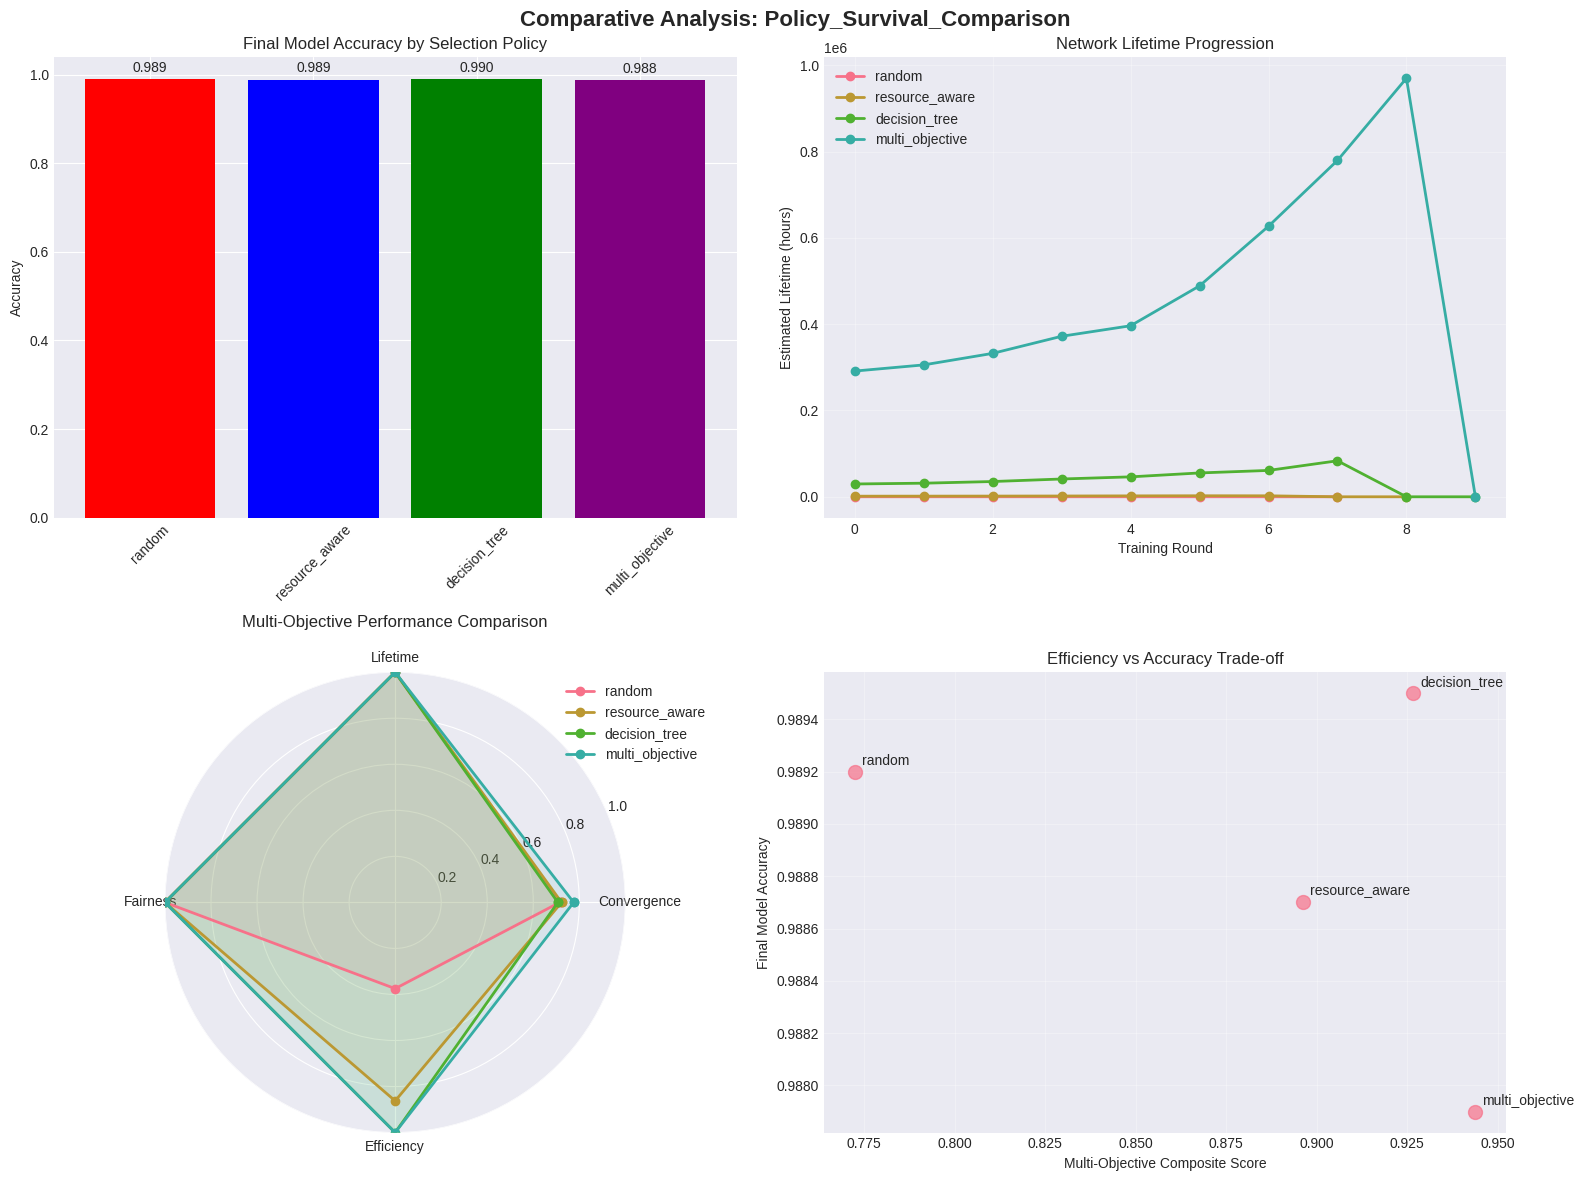

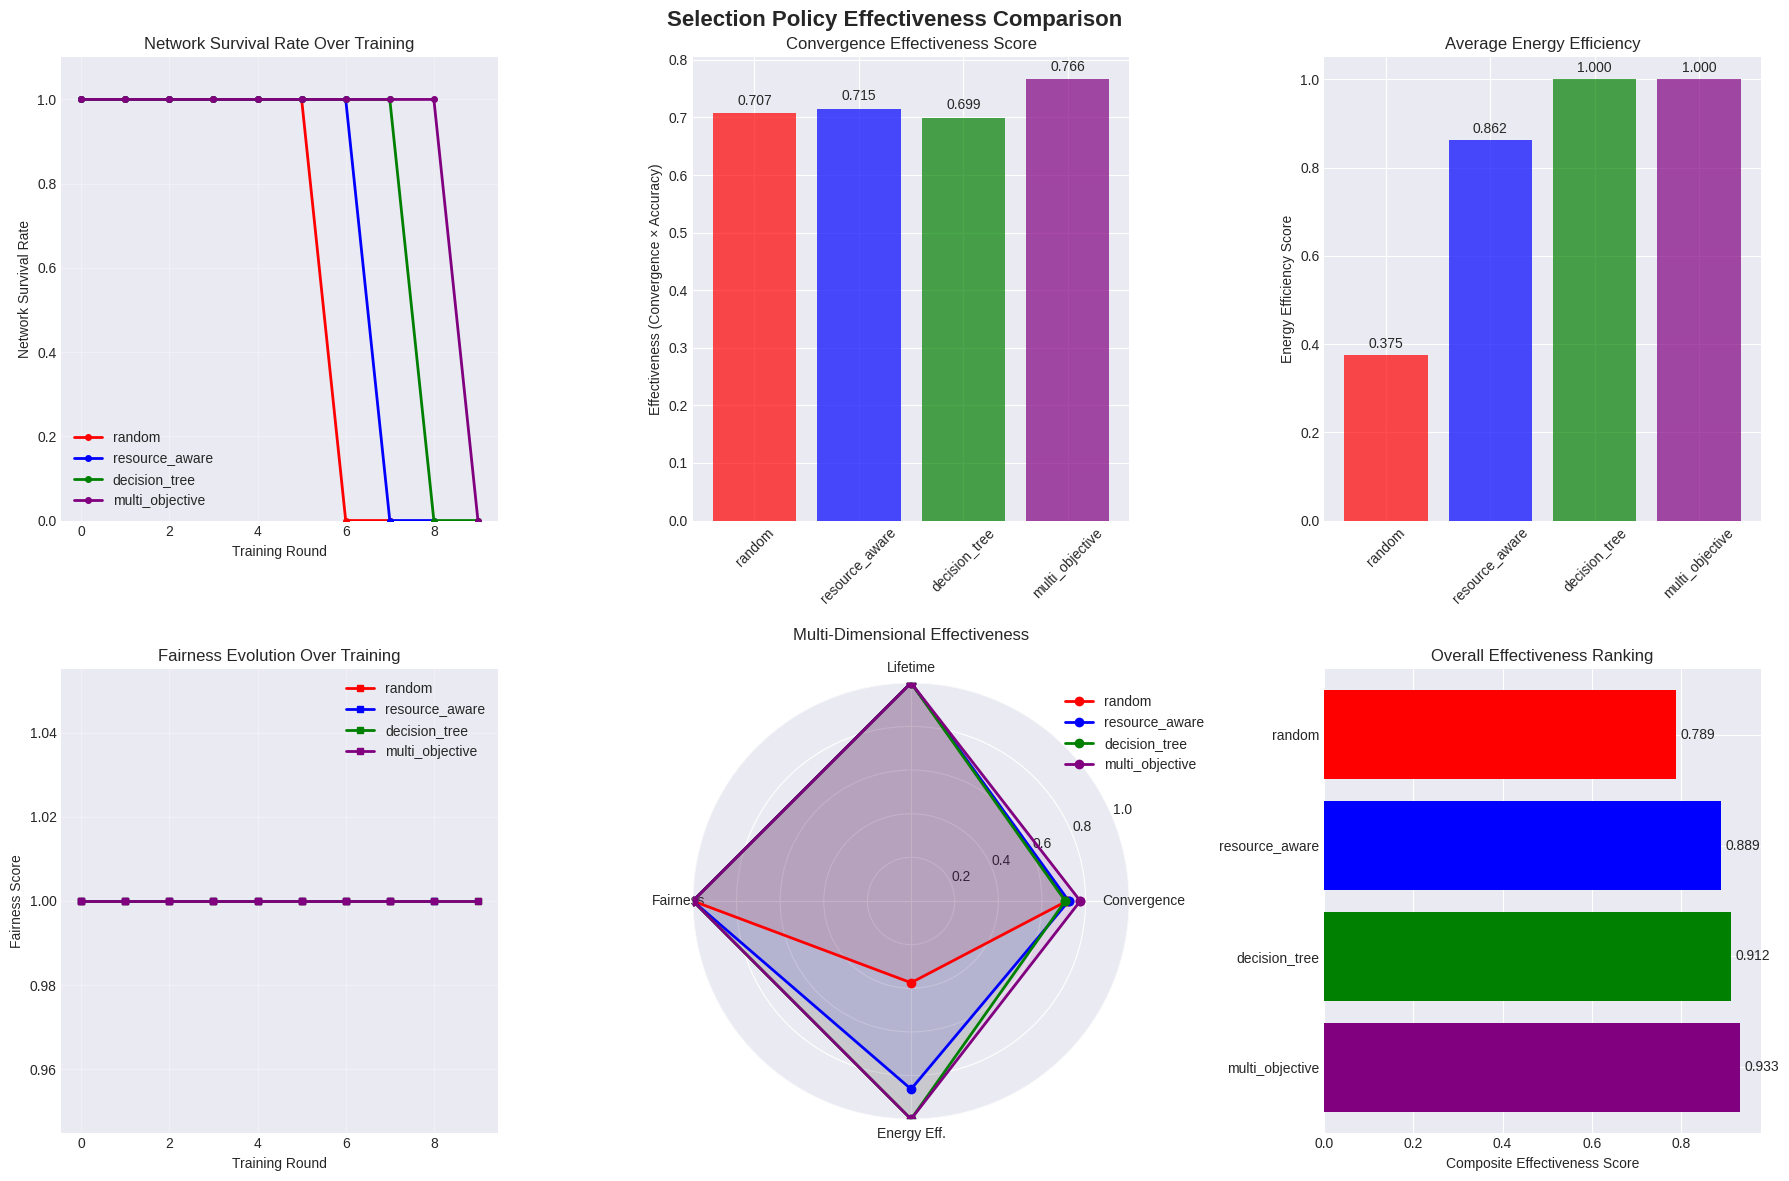

Network survival analysis saved to 'network_survival_analysis.png'


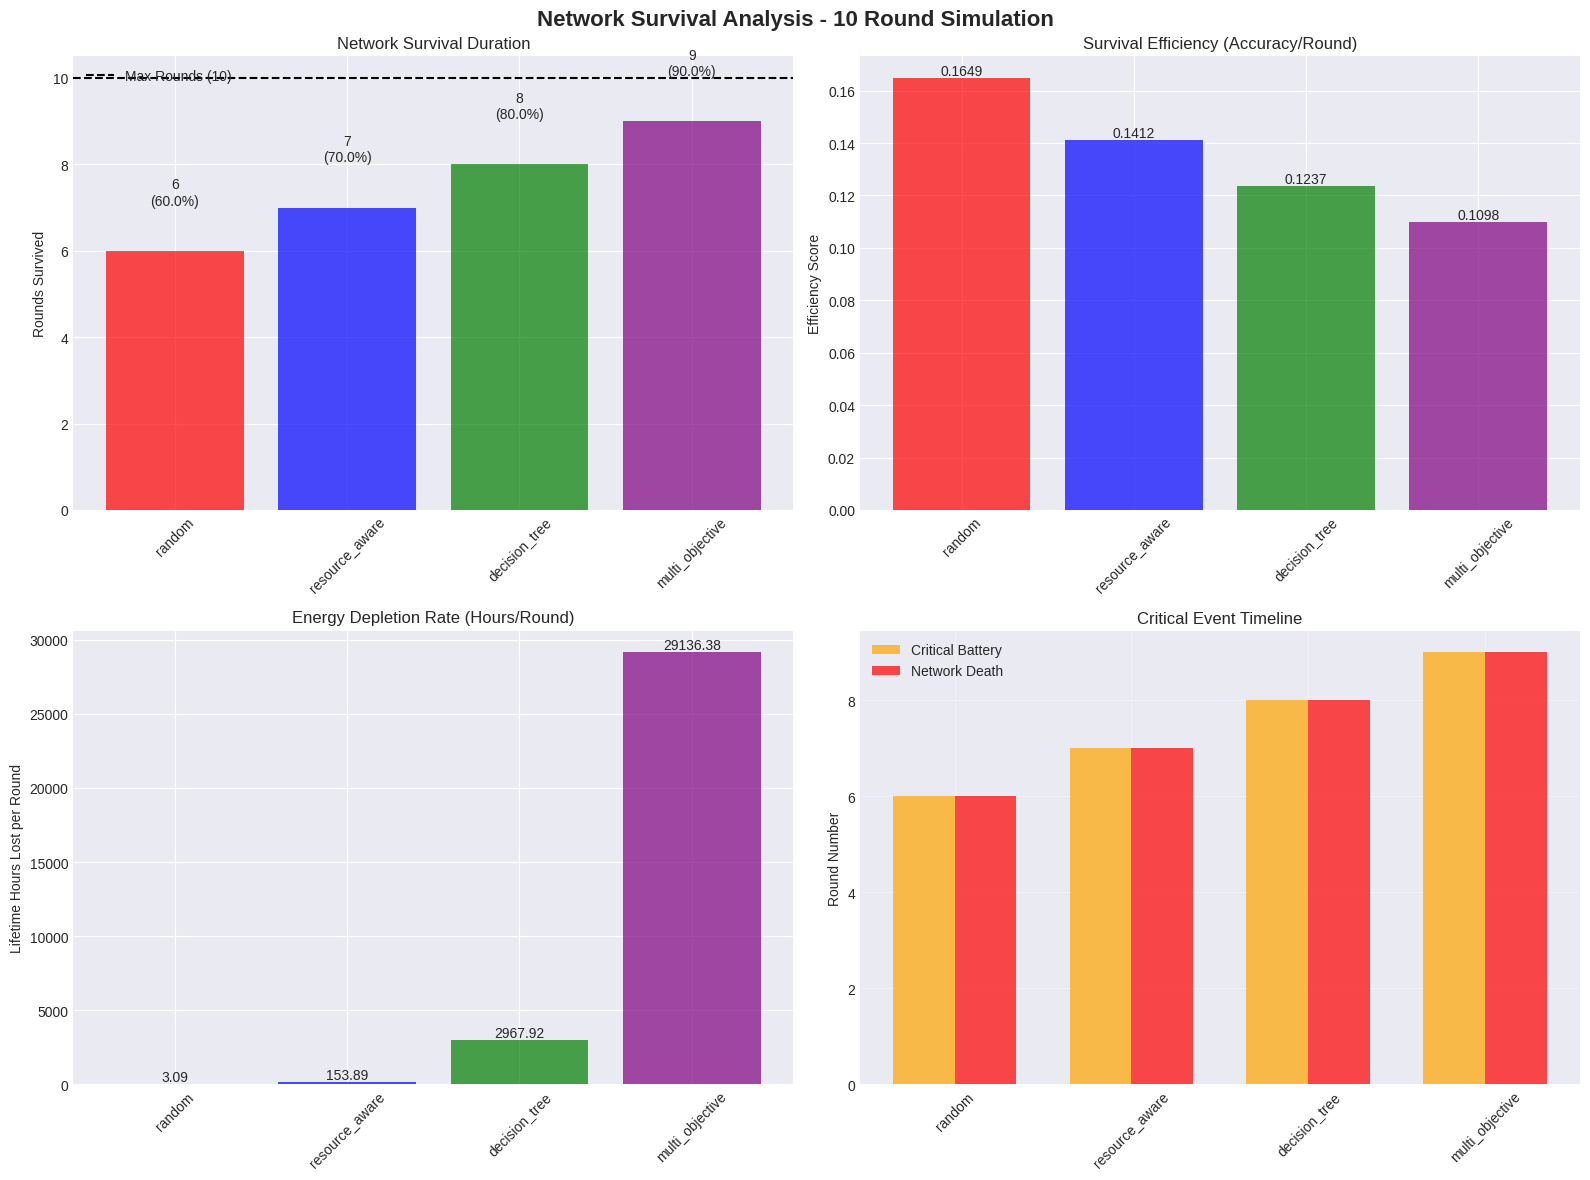


NETWORK SURVIVAL ANALYSIS - 10 ROUND SIMULATION

🏆 SURVIVAL RANKING:
  1. multi_objective - 9/10 rounds (90.0%)
  2. decision_tree   - 8/10 rounds (80.0%)
  3. resource_aware  - 7/10 rounds (70.0%)
  4. random          - 6/10 rounds (60.0%)

⚡ EFFICIENCY RANKING (Accuracy/Round):
  1. random          - 0.16487
  2. resource_aware  - 0.14124
  3. decision_tree   - 0.12369
  4. multi_objective - 0.10977

🔋 ENERGY SUSTAINABILITY (Lower = Better):
  1. random          - 3.089 hours/round
  2. resource_aware  - 153.886 hours/round
  3. decision_tree   - 2967.917 hours/round
  4. multi_objective - 29136.381 hours/round


EXPERIMENT SUMMARY: Policy_Survival_Comparison

📊 ACCURACY RANKING:
  1. decision_tree   - 0.9895
  2. random          - 0.9892
  3. resource_aware  - 0.9887
  4. multi_objective - 0.9879

🎯 MULTI-OBJECTIVE PERFORMANCE:
  random          - Composite Score: 0.772
                   - Convergence: 0.715, Lifetime: 1.000, Fairness: 1.000, Efficiency: 0.375
  resource_aware  - 

{'experiment_name': 'Policy_Survival_Comparison',
 'results': {'random': {'policy': 'random',
   'rounds_completed': 8,
   'rounds_attempted': 10,
   'network_survived_rounds': 8,
   'final_accuracy': 0.9892,
   'final_network_lifetime': 0,
   'accuracy_history': [0.9714,
    0.9857,
    0.9879,
    0.9899,
    0.9888,
    0.9896,
    0.9895,
    0.9892],
   'network_lifetime_progression': [24.713752819784442,
    27.21083730412804,
    28.086694776725228,
    30.341556718433154,
    32.5123920214595,
    27.969356153746467,
    0,
    0],
   'devices_selected_history': [4, 4, 4, 4, 4, 4, 4, 4],
   'active_devices_history': [14, 14, 14, 14, 14, 14, 14, 14],
   'objective_values': {'convergence_speed': [0.707617659788373,
     0.7172417257378549,
     0.7212396703219612,
     0.7525026560848218,
     0.7323160617801507,
     0.703883589385931,
     0.7005426312902192,
     0.6835126726738066],
    'network_lifetime': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'fairness': [1.0, 1.0, 1

In [26]:
def run_policy_comparison():
    """Run the corrected policy comparison"""
    
    # Create experiment configuration
    config = ExperimentConfig("Policy_Survival_Comparison")
    config.num_rounds = 10
    config.selection_policies = ['random', 'resource_aware', 'decision_tree', 'multi_objective']
    config.selection_size = 4
    
    # Create and setup simulation environment
    sim_env = FederatedLearningSystem(
        selection_size=4, 
        simulation_area=(300, 300),
        enable_multi_objective=True
    )
    
    # Add devices (same as your existing setup)
    sim_env.add_device_cluster(cluster_center=(50, 50), cluster_radius=30, device_count=3, device_type="sensor")
    sim_env.add_device_cluster(cluster_center=(250, 250), cluster_radius=40, device_count=5, device_type="camera")
    sim_env.add_device_cluster(cluster_center=(150, 150), cluster_radius=25, device_count=2, device_type="tracker")
    
    # Add individual devices
    sim_env.add_device("temp_sensor", "sensor", initial_battery=95, location=(100, 200))
    sim_env.add_device("security_camera", "camera", initial_battery=35, location=(20, 160))
    sim_env.add_device("asset_tracker", "tracker", initial_battery=70, location=(130, 196))
    sim_env.add_device("door_actuator", "actuator", initial_battery=60, location=(200, 100))
    
    print(f"Created simulation with {len(sim_env.gateway.connected_devices)} devices")
    
    # Run experiment
    experiment_runner = ExperimentRunner(config)
    results = experiment_runner.run_comparative_experiment_s1(sim_env)
    experiment_runner.print_experiment_summary()
    
    return results

# Run
run_policy_comparison()

##### 9.2. (S2) Run Multi-Objective Simulation with best scored policy at each round

In [ ]:
# sim_env = FederatedLearningSystem(selection_size=10, simulation_area=(300, 300))

# # Add various device clusters
# sim_env.add_device_cluster(cluster_center=(50, 50), cluster_radius=30, device_count=3, device_type="sensor")
# sim_env.add_device_cluster(cluster_center=(250, 250), cluster_radius=40, device_count=5, device_type="camera")
# sim_env.add_device_cluster(cluster_center=(150, 150), cluster_radius=25, device_count=2, device_type="tracker")

# # Add individual special devices
# sim_env.add_device("temp_sensor", "sensor", initial_battery=95, location=(100, 200))
# sim_env.add_device("security_camera", "camera", initial_battery=35, location=(20, 160))
# sim_env.add_device("asset_tracker", "tracker", initial_battery=70, location=(130, 196))
# sim_env.add_device("door_actuator", "actuator", initial_battery=60, location=(200, 100))

# logger.info(f"Created simulation with {len(sim_env.gateway.connected_devices)} devices")

# # Run simulation
# sim_env.run_simulation(num_rounds=50, policy="random")
